# Recomputing the Köppen ram-pressure criterion for the MAUVE sample — Model C

**Date:** 2026-08-17  
**Scope:** all 40 physical galaxies in the current MAUVE master catalogue  
**Purpose:** a controlled reproduction of the Köppen et al. (2018) pressure diagnostic with updated, explicitly documented observational inputs and a galaxy-dependent Wang et al. (2016) initial H I cutoff.

This notebook answers a deliberately narrow question:

> Given the present H I deficit, what stripping pressure is required in the Köppen analytic disk model, and is that pressure larger than the maximum local pressure available at the galaxy's projected Virgo-centric radius?

The key diagnostic is

$$
\mathcal{R}_{\rm RP}=\frac{p_{\rm def}}{p_{\rm loc}},\qquad
\Delta_{\rm RP}=\log_{10}\mathcal{R}_{\rm RP}.
$$

Köppen et al. use a factor-of-two margin: $p_{\rm def}>2p_{\rm loc}$ is evidence that the observed deficit cannot be produced at the current projected position under the most favourable local velocity, and therefore favours **past stripping**. It is not a complete orbital reconstruction and it is not, by itself, a proof of a unique evolutionary history.

## 1. Revised roadmap and what is held fixed

This is **Level 1: controlled reproduction using preferred Model C**.

1. Build one row per physical MAUVE galaxy. `NGC4567` and `NGC4568` remain separate; no combined `NGC4567_8` row is introduced.
2. Read observed $\log M_{\rm HI}$ and infall stage from the live local MAUVE master file.
3. Use a frozen 2026-08-15 HyperLeda snapshot for `logd25`, Hubble stage $T$, and rotation speed $v_{\rm rot}$.
4. Convert `logd25` to a physical optical diameter at the MAUVE distance, then define $R_{\rm opt}=D_{25}/2$.
5. Estimate the initial H I mass with the Jones et al. (2018) AMIGA morphology-dependent relation and calculate
   $\mathrm{DEF}=\log M_{\rm HI,0}-\log M_{\rm HI,obs}$.
6. Infer a galaxy-dependent initial H I diameter using Wang et al. (2016),
   $\log D_{\rm HI,0}=0.506\log M_{\rm HI,0}-3.293$, and set $r_{\max}=D_{\rm HI,0}/2$.
7. Keep the Köppen H I profile shape, disk restoring-force approximation, Virgo ICM beta model, and Virgo dark-matter beta model unchanged.
8. Preserve the continuous pressure ratio and propagate AMIGA, Wang, and observational uncertainties with Monte Carlo draws.
9. Compare the result across the MAUVE pre-/close-/post-peak labels without imposing an expected ordering.

### Important scope boundary

This notebook intentionally follows the same core $p_{\rm def}/p_{\rm loc}$ workflow and cell layout as the 2026-08-15 notebook. The configuration-space proxy $p_{\rm cfg}$ remains a separate extension and is not mixed into this controlled Model-C calculation.

## 2. Provenance ledger

| Quantity | Adopted source in this notebook | Role / caveat |
|---|---|---|
| MAUVE membership, $\log M_{\rm HI,obs}$, LOS velocity, stage | local `mauve_master_wiki_newclass.fits` | The FITS table is the live MAUVE compilation. Its `vel` column is treated as heliocentric, although the header does not document its frame or row-level provenance. It does **not** encode a per-row literature reference or uncertainty for H I mass, so this notebook does not claim that all values originate from one survey. |
| `logd25`, `e_logd25`, $T$, $e_T$, $v_{\rm rot}$, formal error | HyperLeda live query, frozen on 2026-08-15 | Embedded below for reproducibility. HyperLeda defines `logd25` as $\log_{10}(D_{25}/0.1\,\mathrm{arcmin})$. |
| Initial H I mass | Jones et al. (2018), AMIGA | Morphology-dependent fit is fiducial; the all-type fit is retained as a sensitivity check. Intrinsic scatter is propagated. |
| Initial H I diameter | Wang et al. (2016) | $D_{\rm HI}$ is defined at $1\,M_\odot\,\mathrm{pc}^{-2}$; the 0.06 dex relation scatter is propagated. |
| Sky coordinates | local `simbad_object_crosswalk.csv` beside this notebook | Frozen SIMBAD cross-match used only for projected separation from M87. |
| Galaxy identity colours | local `MAUVE_galaxy_colors.dat` | Fixed project palette; black is not used for individual galaxies. |
| Virgo/Köppen physics | Köppen et al. (2018) | Held fixed in the controlled reproduction. |

Primary references:

- [Wang et al. 2016, MNRAS 460, 2143](https://academic.oup.com/mnras/article/460/2/2143/2609089)
- [Köppen et al. 2018, MNRAS 479, 4367](https://academic.oup.com/mnras/article/479/4/4367/5040236)
- [Jones et al. 2018, A&A 609, A17](https://www.aanda.org/articles/aa/full_html/2018/01/aa31448-17/aa31448-17.html)
- [HyperLeda query documentation](https://queryhyperleda.readthedocs.io/en/latest/examples.html)

The adopted common distance is 16.5 Mpc, consistent with the current MAUVE environmental workflow. It is held fixed rather than sampled because the master H I masses have not been supplied with enough provenance to rescale every row self-consistently with a distance draw.

For M87, this notebook adopts the current [SIMBAD heliocentric radial velocity](https://simbad.cds.unistra.fr/simbad/sim-basic?Ident=M87), $1256\pm36$ km s$^{-1}$.

In [1]:
# Core scientific and display dependencies.
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from astropy.coordinates import SkyCoord
from astropy.table import Table
import astropy.units as u
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:.4g}")

# Reproducibility controls and fixed project choices.
RNG_SEED = 20260815
N_MC = 20_000
DISTANCE_MPC = 16.5
SIGMA_LOG_MHI_OBS_DEX = 0.10
VROT_FRACTIONAL_FALLBACK = 0.01
SIGMA_LOG_PLOC_DEX = np.log10(2.0)
M87_VLOS_KMS = 1256.0
M87_VLOS_ERR_KMS = 36.0

# Köppen et al. disk parameters.
WANG_SLOPE = 0.506
WANG_INTERCEPT = -3.293
WANG_SCATTER_DEX = 0.06
RESTORING_G = 2.0
STELLAR_BOOST_A = 15.0
R0_AT_ROPT_15_KPC = 2.0  # kpc

# Köppen et al. Virgo ICM and dark-matter beta models.
ICM_N0_CM3 = 0.04
ICM_RC_KPC = 13.4
ICM_BETA = 0.47
DM_RHO0_MSUN_PC3 = 3.8e-4
DM_RC_KPC = 320.0
DM_BETA = 1.0
G_KPC_KMS2_MSUN = 4.30091e-6

# One solar mass of atomic hydrogen spread over one square parsec gives this
# H-atom column; dividing by one kpc converts column/radius to number density.
MSUN_PC2_TO_H_CM2 = 1.2480e20
KPC_TO_CM = 3.0856775814913673e21
SURFACE_OVER_KPC_TO_CM3 = MSUN_PC2_TO_H_CM2 / KPC_TO_CM

HERE = Path.cwd()
MASTER_PATH = HERE / "mauve_master_wiki_newclass.fits"
COLOR_PATH = HERE / "MAUVE_galaxy_colors.dat"
COORD_PATH = HERE / "simbad_object_crosswalk.csv"

print(f"Working directory: {HERE}")
print(f"Monte Carlo draws per galaxy: {N_MC:,}")

Working directory: /Users/Igniz/Desktop/ICRAR/further
Monte Carlo draws per galaxy: 20,000


## 3. Assemble the 40-galaxy analysis table

The joins below are intentionally strict. A missing galaxy, duplicate identifier, or accidental combined-pair name should stop the notebook immediately rather than produce a partially matched result.

The fixed colour file is read independently of catalogue row order. This matters because plotting colours should continue to identify the same physical galaxy after sorting by stage, pressure, or deficiency.

In [2]:
def clean_text(value):
    """Decode byte strings from FITS tables and remove surrounding whitespace."""
    if isinstance(value, (bytes, np.bytes_)):
        value = value.decode("utf-8")
    return str(value).strip()


def read_mauve_colors(path):
    """Read the approved project colour mapping, ignoring its comment header."""
    colors = {}
    with open(path, "r", encoding="utf-8") as handle:
        for line in handle:
            if not line.strip() or line.lstrip().startswith("#"):
                continue
            fields = line.split()
            colors[fields[1]] = fields[3]
    return colors


master = Table.read(MASTER_PATH).to_pandas()
master["Galaxy"] = master["Galaxy"].map(clean_text)
master["stage"] = master["class"].astype(int)
master["stage_label"] = master["stage"].map({1: "pre-peak", 2: "close-to-peak", 3: "post-peak"})

coords = pd.read_csv(COORD_PATH).rename(columns={"component": "Galaxy"})
coords["Galaxy"] = coords["Galaxy"].map(clean_text)

galaxy_colors = read_mauve_colors(COLOR_PATH)

assert len(master) == 40, f"Expected 40 physical MAUVE galaxies, found {len(master)}"
assert master["Galaxy"].is_unique, "The MAUVE master catalogue contains duplicate galaxy IDs"
assert "NGC4567_8" not in set(master["Galaxy"]), "Combined pair ID found in a component-level analysis"
assert set(master["Galaxy"]) == set(coords["Galaxy"]), "SIMBAD cross-match does not match the MAUVE sample"
assert set(master["Galaxy"]).issubset(galaxy_colors), "Fixed colours are missing for one or more galaxies"

sample = master.merge(
    coords[["Galaxy", "main_id", "ra_deg", "dec_deg", "coordinate_bibcode"]],
    on="Galaxy",
    how="left",
    validate="one_to_one",
)
sample["galaxy_color"] = sample["Galaxy"].map(galaxy_colors)

display(sample[["Galaxy", "logMHI", "vel", "stage_label", "main_id", "ra_deg", "dec_deg"]])
print("Strict sample assembly passed: 40 unique component galaxies.")

,Galaxy,logMHI,vel,stage_label,main_id,ra_deg,dec_deg
0,NGC4189,8.78,1995,pre-peak,NGC 4189,183.4,13.42
1,NGC4192,9.655,-118,pre-peak,M 98,183.5,14.9
2,NGC4222,8.832,225,pre-peak,NGC 4222,184.1,13.31
3,NGC4254,9.673,2453,pre-peak,M 99,184.7,14.42
4,NGC4294,9.24,421,pre-peak,NGC 4294,185.3,11.51
5,NGC4321,9.486,1579,pre-peak,M 100,185.7,15.82
6,NGC4351,8.503,2388,pre-peak,NGC 4351,186,12.21
7,NGC4383,9.492,1663,pre-peak,NGC 4383,186.4,16.47
8,NGC4396,8.963,-115,pre-peak,NGC 4396,186.5,15.67
9,NGC4535,9.542,1973,pre-peak,NGC 4535,188.6,8.198


Strict sample assembly passed: 40 unique component galaxies.


## 4. Frozen HyperLeda input snapshot

The table below is embedded, rather than queried during execution, so the notebook remains reproducible if the live database changes or is temporarily unavailable.

- `logd25`: $\log_{10}$ of the apparent major-axis diameter in units of 0.1 arcmin.
- `T`: numerical Hubble stage used to choose the morphology-dependent AMIGA relation.
- `vrot`: reported HyperLeda homogenized maximum rotation velocity in km s$^{-1}$.
- `e_vrot`: literature/catalogue uncertainty on that reported velocity where available.

The Monte Carlo now follows one explicit rule:

$$
\sigma(v_{\rm rot})=
\begin{cases}
e(v_{\rm rot}), & e(v_{\rm rot})\ 	ext{is finite and positive},\\
0.01v_{\rm rot}, & \text{otherwise}.
\end{cases}
$$

Thus the 1% value is only a fallback for missing literature uncertainty; it is not a floor applied to every galaxy.

In [3]:
HYPERLEDA_CSV = """Galaxy,logd25,e_logd25,t,e_t,vrot,e_vrot,hl_type
NGC4189,1.34,0.03,5.9,0.9,195.9,4.7,Sc
NGC4192,2.04,0.02,2.6,0.8,216.0,,SABb
NGC4222,1.45,0.03,6.6,1.1,99.8,,Scd
NGC4254,1.70,0.03,5.2,0.7,299.5,8.8,Sc
NGC4294,1.43,0.03,5.9,0.5,94.9,2.1,SBc
NGC4321,1.78,0.02,4.0,0.3,278.6,6.2,SABb
NGC4351,1.20,0.04,2.8,1.7,67.2,1.9,SBb
NGC4383,1.22,0.07,0.8,0.8,103.3,2.5,Sa
NGC4396,1.47,0.04,6.8,0.8,89.0,2.2,Scd
NGC4535,1.91,0.02,5.0,0.4,304.3,6.8,Sc
NGC4567,1.44,0.02,4.0,0.3,224.4,5.3,Sbc
NGC4568,1.63,0.03,4.1,0.3,165.5,7.8,Sbc
NGC4298,1.40,0.05,5.1,0.6,190.2,5.2,Sc
NGC4302,1.78,0.03,5.3,0.8,167.8,,Sc
NGC4330,1.36,0.03,6.1,0.6,114.4,3.4,Sc
NGC4388,1.73,0.02,2.8,0.7,171.1,,SBb
NGC4402,1.55,0.02,3.2,0.8,114.4,2.8,Sb
NGC4424,1.48,0.03,1.3,1.6,28.6,1.1,Sa
NGC4501,1.94,0.03,3.3,0.6,272.1,4.4,Sb
NGC4522,1.54,0.02,5.9,0.6,96.3,2.5,Sc
NGC4654,1.67,0.02,5.9,0.5,149.6,2.1,Sc
NGC4694,1.30,0.04,-1.8,0.7,50.3,1.6,S0
NGC4064,1.51,0.03,1.2,1.8,84.9,2.9,SBa
NGC4216,1.89,0.01,3.0,0.5,244.8,,SABb
NGC4293,1.79,0.03,0.3,0.8,125.9,4.4,S0-a
NGC4380,1.52,0.03,2.4,0.9,144.7,3.7,SABa
NGC4394,1.54,0.02,3.0,0.4,238.3,8.7,SBb
NGC4405,1.18,0.06,0.3,1.1,75.8,2.9,S0-a
NGC4419,1.59,0.04,1.2,0.9,100.4,2.6,Sa
NGC4450,1.74,0.02,2.4,0.7,184.7,4.6,Sab
IC3392,1.41,0.05,2.4,0.8,80.6,2.4,Sab
NGC4457,1.45,0.03,0.3,1.1,101.3,3.2,S0-a
NGC4548,1.74,0.03,3.1,0.5,177.6,4.8,Sb
NGC4569,1.96,0.02,2.4,0.7,185.8,5.4,Sab
NGC4579,1.70,0.02,2.8,0.6,249.5,7.3,Sb
NGC4580,1.27,0.03,1.6,0.7,104.7,3.2,SABa
NGC4606,1.39,0.04,0.6,1.4,70.2,2.2,SBa
NGC4607,1.46,0.03,4.0,2.2,99.1,,SBbc
NGC4689,1.58,0.03,4.7,0.9,120.5,2.4,Sc
NGC4698,1.58,0.02,1.6,1.0,203.0,3.2,Sab
"""

hyperleda = pd.read_csv(StringIO(HYPERLEDA_CSV))
assert len(hyperleda) == 40 and hyperleda["Galaxy"].is_unique
assert set(sample["Galaxy"]) == set(hyperleda["Galaxy"]), "HyperLeda snapshot/sample mismatch"

sample = sample.merge(hyperleda, on="Galaxy", how="left", validate="one_to_one")
has_literature_evrot = np.isfinite(sample["e_vrot"]) & (sample["e_vrot"] > 0)
sample["e_vrot_used"] = np.where(
    has_literature_evrot,
    sample["e_vrot"],
    VROT_FRACTIONAL_FALLBACK * sample["vrot"],
)
sample["e_vrot_source"] = np.where(
    has_literature_evrot, "literature e_vrot", "1% of reported vrot",
)

assert sample[["logd25", "e_logd25", "t", "e_t", "vrot"]].notna().all().all()
display(sample[["Galaxy", "logd25", "e_logd25", "t", "e_t", "hl_type", "vrot", "e_vrot", "e_vrot_used", "e_vrot_source"]])
print("HyperLeda coverage: 40/40 for logd25, T, and vrot.")

,Galaxy,logd25,e_logd25,t,e_t,hl_type,vrot,e_vrot,e_vrot_used,e_vrot_source
0,NGC4189,1.34,0.03,5.9,0.9,Sc,195.9,4.7,4.7,literature e_vrot
1,NGC4192,2.04,0.02,2.6,0.8,SABb,216,NaN,2.16,1% of reported vrot
2,NGC4222,1.45,0.03,6.6,1.1,Scd,99.8,NaN,0.998,1% of reported vrot
3,NGC4254,1.7,0.03,5.2,0.7,Sc,299.5,8.8,8.8,literature e_vrot
4,NGC4294,1.43,0.03,5.9,0.5,SBc,94.9,2.1,2.1,literature e_vrot
5,NGC4321,1.78,0.02,4,0.3,SABb,278.6,6.2,6.2,literature e_vrot
6,NGC4351,1.2,0.04,2.8,1.7,SBb,67.2,1.9,1.9,literature e_vrot
7,NGC4383,1.22,0.07,0.8,0.8,Sa,103.3,2.5,2.5,literature e_vrot
8,NGC4396,1.47,0.04,6.8,0.8,Scd,89,2.2,2.2,literature e_vrot
9,NGC4535,1.91,0.02,5,0.4,Sc,304.3,6.8,6.8,literature e_vrot


HyperLeda coverage: 40/40 for logd25, T, and vrot.


## 5. Optical diameter and the AMIGA expected-H I calibration

HyperLeda's definition gives

$$
D_{25}[\mathrm{arcmin}]=0.1\,10^{\mathrm{logd25}}.
$$

At the fixed MAUVE distance, the angular diameter is converted to kpc and
$R_{\rm opt}=D_{25}/2$.

The fiducial Jones et al. (2018) relation is

$$
\log M_{\rm HI,exp}=A_T\,[2\log D_{25}(\mathrm{kpc})]+B_T,
$$

with $(A_T,B_T,\sigma_{\rm int})=(1.04,6.44,0.27)$ for $T<3$,
$(0.93,7.14,0.16)$ for $3\le T\le5$, and $(0.81,7.53,0.17)$ for $T>5$.

The all-type comparison relation is

$$
\log M_{\rm HI,exp,all}=1.72\log D_{25}(\mathrm{kpc})+7.30
$$

with 0.21 dex intrinsic scatter. The morphology-dependent value is the primary result; the all-type value is retained to expose sensitivity to calibration choice.

Model C converts the AMIGA initial mass into an initial H I diameter using Wang et al. (2016):

$$
\log_{10}\left(\frac{D_{\rm HI,0}}{\mathrm{kpc}}\right)
=0.506\log_{10}\left(\frac{M_{\rm HI,0}}{M_\odot}\right)-3.293.
$$

The initial profile cutoff is therefore galaxy dependent:

$$
r_{\max}=\frac{D_{\rm HI,0}}{2},
$$

rather than the fixed $1.5R_{\rm opt}$ used in the 2026-08-15 notebook.

In [4]:
def angular_diameter_kpc(logd25, distance_mpc=DISTANCE_MPC):
    """Convert HyperLeda logd25 to physical D25 in kpc using the small-angle relation."""
    d25_arcmin = 0.1 * np.power(10.0, np.asarray(logd25))
    return np.deg2rad(d25_arcmin / 60.0) * distance_mpc * 1_000.0


def amiga_parameters(t_stage):
    """Return Jones+2018 morphology-dependent A, B, and intrinsic scatter."""
    t_stage = np.asarray(t_stage)
    a = np.select([t_stage < 3, t_stage <= 5], [1.04, 0.93], default=0.81)
    b = np.select([t_stage < 3, t_stage <= 5], [6.44, 7.14], default=7.53)
    scatter = np.select([t_stage < 3, t_stage <= 5], [0.27, 0.16], default=0.17)
    return a, b, scatter


sample["D25_arcmin"] = 0.1 * 10.0 ** sample["logd25"]
sample["D25_kpc"] = angular_diameter_kpc(sample["logd25"])
sample["Ropt_kpc"] = 0.5 * sample["D25_kpc"]

a_t, b_t, scatter_t = amiga_parameters(sample["t"])
sample["amiga_A"] = a_t
sample["amiga_B"] = b_t
sample["amiga_scatter_dex"] = scatter_t
sample["logMHI_exp"] = a_t * (2.0 * np.log10(sample["D25_kpc"])) + b_t
sample["logMHI_exp_all"] = 1.72 * np.log10(sample["D25_kpc"]) + 7.30
sample["DEF"] = sample["logMHI_exp"] - sample["logMHI"]
sample["DEF_all"] = sample["logMHI_exp_all"] - sample["logMHI"]
sample["DHI0_Wang_kpc"] = 10.0 ** (WANG_SLOPE * sample["logMHI_exp"] + WANG_INTERCEPT)
sample["rmax_kpc"] = 0.5 * sample["DHI0_Wang_kpc"]
sample["rmax_over_Ropt"] = sample["rmax_kpc"] / sample["Ropt_kpc"]
sample["amiga_applicability_note"] = np.where(
    sample["t"] < 0,
    "T<0: early-type extrapolation; interpret cautiously",
    "within adopted T-bin implementation",
)

display(sample[[
    "Galaxy", "stage_label", "t", "D25_arcmin", "D25_kpc", "Ropt_kpc",
    "logMHI", "logMHI_exp", "DEF", "DEF_all", "DHI0_Wang_kpc", "rmax_kpc", "rmax_over_Ropt", "amiga_scatter_dex",
    "amiga_applicability_note",
]])

,Galaxy,stage_label,t,D25_arcmin,D25_kpc,Ropt_kpc,logMHI,logMHI_exp,DEF,DEF_all,DHI0_Wang_kpc,rmax_kpc,rmax_over_Ropt,amiga_scatter_dex,amiga_applicability_note
0,NGC4189,pre-peak,5.9,2.188,10.5,5.25,8.78,9.184,0.4041,0.2762,22.61,11.3,2.153,0.17,within adopted T-bin implementation
1,NGC4192,pre-peak,2.6,10.96,52.63,26.31,9.655,10.02,0.3648,0.6051,59.87,29.93,1.138,0.27,within adopted T-bin implementation
2,NGC4222,pre-peak,6.6,2.818,13.53,6.764,8.832,9.363,0.5305,0.4136,27.83,13.91,2.057,0.17,within adopted T-bin implementation
3,NGC4254,pre-peak,5.2,5.012,24.06,12.03,9.673,9.768,0.09461,0.002731,44.61,22.3,1.854,0.17,within adopted T-bin implementation
4,NGC4294,pre-peak,5.9,2.692,12.92,6.459,9.24,9.33,0.09037,-0.02851,26.8,13.4,2.074,0.17,within adopted T-bin implementation
5,NGC4321,pre-peak,4,6.026,28.92,14.46,9.486,9.858,0.3721,0.3275,49.55,24.78,1.713,0.16,within adopted T-bin implementation
6,NGC4351,pre-peak,2.8,1.585,7.607,3.803,8.503,8.273,-0.2297,0.3131,7.818,3.909,1.028,0.27,within adopted T-bin implementation
7,NGC4383,pre-peak,0.8,1.66,7.965,3.983,9.492,8.315,-1.177,-0.6417,8.206,4.103,1.03,0.27,within adopted T-bin implementation
8,NGC4396,pre-peak,6.8,2.951,14.16,7.082,8.963,9.395,0.4322,0.3173,28.9,14.45,2.04,0.17,within adopted T-bin implementation
9,NGC4535,pre-peak,5,8.128,39.01,19.51,9.542,10.1,0.5574,0.4946,65.68,32.84,1.684,0.16,within adopted T-bin implementation


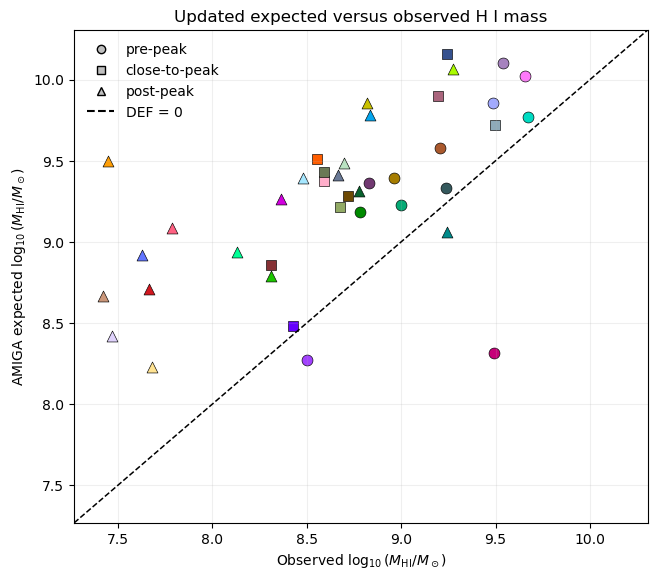

Central-input negative DEF galaxies (3): NGC4383, NGC4351, NGC4698


,Galaxy,stage_label,logMHI,logMHI_exp,DEF
7,NGC4383,pre-peak,9.492,8.315,-1.177
6,NGC4351,pre-peak,8.503,8.273,-0.2297
39,NGC4698,post-peak,9.241,9.063,-0.1776


In [5]:
# First diagnostic: where the updated expected masses sit relative to the observed compilation.
stage_markers = {1: "o", 2: "s", 3: "^"}
stage_labels = {1: "pre-peak", 2: "close-to-peak", 3: "post-peak"}

fig, ax = plt.subplots(figsize=(7.4, 6.4))
for _, row in sample.iterrows():
    ax.scatter(
        row["logMHI"], row["logMHI_exp"],
        marker=stage_markers[row["stage"]], s=62,
        color=row["galaxy_color"], edgecolor="black", linewidth=0.45,
    )

limits = [min(sample["logMHI"].min(), sample["logMHI_exp"].min()) - 0.15,
          max(sample["logMHI"].max(), sample["logMHI_exp"].max()) + 0.15]
ax.plot(limits, limits, color="black", linestyle="--", linewidth=1.1, label="DEF = 0")
ax.set(xlim=limits, ylim=limits,
       xlabel=r"Observed $\log_{10}(M_{\rm HI}/M_\odot)$",
       ylabel=r"AMIGA expected $\log_{10}(M_{\rm HI}/M_\odot)$")
ax.grid(alpha=0.2)
handles = [Line2D([], [], marker=stage_markers[s], linestyle="None", color="0.35",
                  markerfacecolor="0.75", markeredgecolor="black", label=stage_labels[s])
           for s in (1, 2, 3)]
handles.append(Line2D([], [], color="black", linestyle="--", label="DEF = 0"))
ax.legend(handles=handles, frameon=False)
ax.set_title("Updated expected versus observed H I mass")
plt.show()

# Report the central-input negative deficiencies explicitly. These are not
# forced to DEF=0 and will not receive a deterministic stripping inversion.
negative_deficiency = sample.loc[
    sample["DEF"] < 0,
    ["Galaxy", "stage_label", "logMHI", "logMHI_exp", "DEF"],
].sort_values("DEF")
print(
    f"Central-input negative DEF galaxies ({len(negative_deficiency)}): "
    + ", ".join(negative_deficiency["Galaxy"])
)
display(negative_deficiency)

## 6. Invert H I deficiency to a Model-C stripping radius

Köppen et al. adopt the initial H I surface-density shape

$$
\Sigma_{\rm HI}(r)=\frac{\Sigma_0}{[1+(r/R)^2]^{3/2}},
\qquad R=R_{\rm opt}.
$$

Model C keeps this shape but uses the galaxy-dependent Wang cutoff $r_{\max}=D_{\rm HI,0}/2$. Normalizing to the AMIGA initial mass $M_0$ gives

$$
\Sigma_0=\frac{M_0}{2\pi R^2 C},\qquad
C=1-\left[1+(r_{\max}/R)^2\right]^{-1/2}.
$$

If all gas outside $r_{\rm strip}$ is removed, the remaining mass fraction is $10^{-\mathrm{DEF}}$. Analytic inversion gives

$$
A=1-C10^{-\mathrm{DEF}},\qquad
r_{\rm strip}=R\sqrt{A^{-2}-1}.
$$

Unlike the earlier notebook, $C$ is recalculated for every galaxy and every Monte Carlo draw. For $\mathrm{DEF}\le0$, the stripping interpretation has no physical missing-H I mass to invert. Those cases are retained but assigned `NaN` for $r_{\rm strip}$ and $p_{\rm def}$; they are never clipped to zero deficiency.

In [6]:
def profile_integral_factor(ropt_kpc, rmax_kpc):
    """Dimensionless mass integral for the truncated Köppen H I profile."""
    ropt_kpc, rmax_kpc = np.broadcast_arrays(
        np.asarray(ropt_kpc, dtype=float), np.asarray(rmax_kpc, dtype=float)
    )
    return 1.0 - 1.0 / np.sqrt(1.0 + (rmax_kpc / ropt_kpc) ** 2)


def stripping_radius_kpc(deficiency, ropt_kpc, rmax_kpc):
    """Analytic radius enclosing 10**(-DEF) of a disk truncated at rmax."""
    deficiency, ropt_kpc, rmax_kpc = np.broadcast_arrays(
        np.asarray(deficiency, dtype=float),
        np.asarray(ropt_kpc, dtype=float),
        np.asarray(rmax_kpc, dtype=float),
    )
    result = np.full(deficiency.shape, np.nan, dtype=float)
    valid = (deficiency > 0.0) & (ropt_kpc > 0.0) & (rmax_kpc > 0.0)
    c_profile = profile_integral_factor(ropt_kpc[valid], rmax_kpc[valid])
    a_term = 1.0 - c_profile * np.power(10.0, -deficiency[valid])
    result[valid] = ropt_kpc[valid] * np.sqrt(np.power(a_term, -2.0) - 1.0)
    return result


def sigma_hi_msun_pc2(r_kpc, ropt_kpc, log_mhi_initial, rmax_kpc):
    """Model-C initial-profile H I surface density evaluated at radius r."""
    r_kpc, ropt_kpc, log_mhi_initial, rmax_kpc = np.broadcast_arrays(
        np.asarray(r_kpc, dtype=float),
        np.asarray(ropt_kpc, dtype=float),
        np.asarray(log_mhi_initial, dtype=float),
        np.asarray(rmax_kpc, dtype=float),
    )
    c_profile = profile_integral_factor(ropt_kpc, rmax_kpc)
    mhi_initial = np.power(10.0, log_mhi_initial)
    sigma0 = mhi_initial / (2.0 * np.pi * (ropt_kpc * 1_000.0) ** 2 * c_profile)
    return sigma0 / np.power(1.0 + (r_kpc / ropt_kpc) ** 2, 1.5)


def required_pressure(deficiency, ropt_kpc, log_mhi_initial, rmax_kpc, vrot_kms):
    """Model-C Köppen p_def in units of 10^3 cm^-3 (km/s)^2."""
    r_strip = stripping_radius_kpc(deficiency, ropt_kpc, rmax_kpc)
    sigma_at_strip = sigma_hi_msun_pc2(r_strip, ropt_kpc, log_mhi_initial, rmax_kpc)
    r0_kpc = R0_AT_ROPT_15_KPC * np.asarray(ropt_kpc) / 15.0
    stellar_boost = 1.0 + STELLAR_BOOST_A * np.exp(-r_strip / r0_kpc)
    p_native = (
        sigma_at_strip
        * np.asarray(vrot_kms) ** 2
        / (RESTORING_G * r_strip)
        * stellar_boost
        * SURFACE_OVER_KPC_TO_CM3
    )
    return p_native / 1_000.0


# Limiting checks for several different galaxy-dependent cutoffs.
for test_cutoff in (1.2, 1.5, 2.5, 4.0):
    test_def = np.array([1e-8, 0.1, 0.5, 1.0, 2.0])
    test_r = stripping_radius_kpc(test_def, np.ones_like(test_def), test_cutoff)
    assert np.isclose(test_r[0], test_cutoff, rtol=1e-6)
    assert np.all(np.diff(test_r) < 0)
assert np.isnan(stripping_radius_kpc(np.array([-0.1, 0.0]), 1.0, 1.5)).all()

# Numerical mass-integration check for the generalized normalization.
r_grid = np.linspace(0.0, 12.0, 200_001)
sigma_grid = sigma_hi_msun_pc2(r_grid, 5.0, 9.5, 12.0)
integrated_mass = np.trapezoid(2.0 * np.pi * (1_000.0 * r_grid) * sigma_grid * 1_000.0, r_grid)
assert np.isclose(integrated_mass, 10.0 ** 9.5, rtol=2e-5)
print("Model-C analytic inversion and profile-normalization checks passed.")

Model-C analytic inversion and profile-normalization checks passed.


## 7. Revised local pressure at projected Virgo-centric radius

The ICM number-density profile remains

$$
n_{\rm ICM}(R)=0.04\left[1+\left(\frac{R}{13.4\,\mathrm{kpc}}\right)^2\right]^{-3(0.47)/2}
\ \mathrm{cm}^{-3}.
$$

For the Köppen dark-matter beta model,

$$
v_{\rm esc}^2(r)=8\pi G\rho_0R_c^2
\frac{\operatorname{asinh}(r/R_c)}{r/R_c}.
$$

In addition to this escape-speed ceiling, we now calculate the directly observed LOS difference from M87:

$$
v_{\rm relative,LOS}=|v_{\rm LOS}-v_{\rm M87}|,
\qquad v_{\rm M87}=1256\pm36\ {\rm km\,s^{-1}},
$$

using SIMBAD's current heliocentric M87 value and the local MAUVE master-table `vel` column. The adopted speed and pressure are

$$
v_{\rm upper}=\max(v_{\rm esc},v_{\rm relative,LOS}),
\qquad p_{\rm loc}=n_{\rm ICM}(R_{\rm proj})v_{\rm upper}^2.
$$

`p_loc_escape_only` is also retained to reproduce the original Köppen prescription. The terminology needs care: $v_{\rm relative,LOS}$ is a lower bound on the unknown 3D relative speed, whereas $v_{\rm esc}$ is an upper bound only for a bound orbit. Therefore `v_upper` is a conservative adopted comparison speed, not a strict dynamical upper limit when the LOS term is larger. Such cases are explicitly labelled `LOS relative velocity`.

The master FITS header does not record a velocity frame or per-row provenance for `vel`; the heliocentric interpretation is an explicit working assumption. The Monte Carlo samples the $36\ {\rm km\,s^{-1}}$ M87 uncertainty and the existing factor-of-two $p_{\rm loc}$ model uncertainty.

In [7]:
M87 = SkyCoord("12h30m49.42338s", "+12d23m28.0439s", frame="icrs")


def escape_speed_squared_kms2(radius_kpc):
    """Analytic escape-speed squared for the Köppen beta_DM=1 halo."""
    radius_kpc = np.asarray(radius_kpc, dtype=float)
    x = radius_kpc / DM_RC_KPC
    shape = np.ones_like(x)
    nonzero = x != 0
    shape[nonzero] = np.arcsinh(x[nonzero]) / x[nonzero]
    rho0_msun_kpc3 = DM_RHO0_MSUN_PC3 * 1.0e9
    return 8.0 * np.pi * G_KPC_KMS2_MSUN * rho0_msun_kpc3 * DM_RC_KPC**2 * shape


def icm_number_density_cm3(radius_mpc):
    """Köppen Virgo ICM number density at projected radius."""
    radius_kpc = np.asarray(radius_mpc, dtype=float) * 1_000.0
    return ICM_N0_CM3 * np.power(
        1.0 + (radius_kpc / ICM_RC_KPC)**2, -1.5 * ICM_BETA
    )


def local_pressure(radius_mpc, velocity_kms=None):
    """p_loc in 10^3 cm^-3 (km/s)^2; default velocity is Köppen v_esc."""
    radius_kpc = np.asarray(radius_mpc, dtype=float) * 1_000.0
    if velocity_kms is None:
        velocity_kms = np.sqrt(escape_speed_squared_kms2(radius_kpc))
    return icm_number_density_cm3(radius_mpc) * np.asarray(velocity_kms)**2 / 1_000.0


galaxy_sky = SkyCoord(sample["ra_deg"].to_numpy() * u.deg, sample["dec_deg"].to_numpy() * u.deg)
sample["m87_separation_deg"] = galaxy_sky.separation(M87).degree
sample["Rproj_mpc"] = np.deg2rad(sample["m87_separation_deg"]) * DISTANCE_MPC

# The local master-table `vel` column is used as the galaxy heliocentric LOS
# velocity. Its FITS header has no per-row provenance or velocity-frame metadata,
# so this frame match is an explicit working assumption rather than a hidden one.
sample["v_los_kms"] = sample["vel"].astype(float)
sample["v_relative_los_kms"] = np.abs(sample["v_los_kms"] - M87_VLOS_KMS)
sample["v_esc_kms"] = np.sqrt(
    escape_speed_squared_kms2(sample["Rproj_mpc"].to_numpy() * 1_000.0)
)
sample["v_upper_kms"] = np.maximum(sample["v_esc_kms"], sample["v_relative_los_kms"])
sample["v_upper_source"] = np.where(
    sample["v_relative_los_kms"] > sample["v_esc_kms"],
    "LOS relative velocity", "Köppen escape speed",
)
sample["n_icm_cm3"] = icm_number_density_cm3(sample["Rproj_mpc"])
sample["p_loc_escape_only"] = local_pressure(sample["Rproj_mpc"])
sample["p_loc"] = local_pressure(sample["Rproj_mpc"], sample["v_upper_kms"])


# Compact rounded appendix values regression-test the original escape-only branch.
PAPER_PLOC_CSV = """Galaxy,Rproj_mpc_paper,p_loc_paper
NGC4438,0.29,1.95
NGC4330,0.63,0.52
NGC4388,0.37,1.27
NGC4522,0.98,0.22
NGC4402,0.40,1.13
NGC4321,1.17,0.16
NGC4298,0.94,0.24
NGC4192,1.43,0.10
NGC4606,3.03,0.02
NGC4450,3.40,0.02
NGC4698,1.73,0.07
"""
paper_ploc = pd.read_csv(StringIO(PAPER_PLOC_CSV))
paper_ploc["p_loc_recomputed"] = local_pressure(paper_ploc["Rproj_mpc_paper"])
paper_ploc["fractional_residual"] = (
    paper_ploc["p_loc_recomputed"] - paper_ploc["p_loc_paper"]
) / paper_ploc["p_loc_paper"]
assert np.median(np.abs(paper_ploc["fractional_residual"])) < 0.10
assert np.max(np.abs(paper_ploc["fractional_residual"])) < 0.30
display(paper_ploc)
display(sample[[
    "Galaxy", "Rproj_mpc", "v_los_kms", "v_relative_los_kms", "v_esc_kms",
    "v_upper_kms", "v_upper_source", "p_loc_escape_only", "p_loc",
]])
print("Published escape-only p_loc regression passed; revised velocity comparison table shown above.")

,Galaxy,Rproj_mpc_paper,p_loc_paper,p_loc_recomputed,fractional_residual
0,NGC4438,0.29,1.95,1.975,0.01299
1,NGC4330,0.63,0.52,0.5358,0.0303
2,NGC4388,0.37,1.27,1.334,0.05038
3,NGC4522,0.98,0.22,0.2375,0.07976
4,NGC4402,0.4,1.13,1.173,0.03781
5,NGC4321,1.17,0.16,0.1693,0.05813
6,NGC4298,0.94,0.24,0.257,0.0708
7,NGC4192,1.43,0.1,0.1145,0.1451
8,NGC4606,3.03,0.02,0.02506,0.2529
9,NGC4450,3.4,0.02,0.01972,-0.01388


,Galaxy,Rproj_mpc,v_los_kms,v_relative_los_kms,v_esc_kms,v_upper_kms,v_upper_source,p_loc_escape_only,p_loc
0,NGC4189,1.232,1995,739,1499,1499,Köppen escape speed,0.1532,0.1532
1,NGC4192,1.393,-118,1374,1450,1450,Köppen escape speed,0.1206,0.1206
2,NGC4222,1.048,225,1031,1563,1563,Köppen escape speed,0.2092,0.2092
3,NGC4254,1.023,2453,1197,1572,1572,Köppen escape speed,0.2191,0.2191
4,NGC4294,0.7173,421,835,1704,1704,Köppen escape speed,0.424,0.424
5,NGC4321,1.132,1579,323,1533,1533,Köppen escape speed,0.1805,0.1805
6,NGC4351,0.4812,2388,1132,1830,1830,Köppen escape speed,0.8585,0.8585
7,NGC4383,1.233,1663,407,1499,1499,Köppen escape speed,0.1529,0.1529
8,NGC4396,1.003,-115,1371,1580,1580,Köppen escape speed,0.2272,0.2272
9,NGC4535,1.233,1973,717,1499,1499,Köppen escape speed,0.153,0.153


Published escape-only p_loc regression passed; revised velocity comparison table shown above.


## 8. Deterministic recomputation

The deterministic calculation uses the central value of every input, including the Wang-inferred initial H I cutoff. It is useful for auditing equations, but it should not be treated as the final classification because the AMIGA relation has intrinsic scatter and $p_{\rm loc}$ alone is uncertain by about a factor of two.

The pressure unit used by the paper and throughout the remaining notebook is
$10^3\,\mathrm{cm}^{-3}(\mathrm{km}\,\mathrm{s}^{-1})^2$.

In [8]:
sample["r_strip_kpc"] = stripping_radius_kpc(
    sample["DEF"], sample["Ropt_kpc"], sample["rmax_kpc"]
)
sample["p_def"] = required_pressure(
    sample["DEF"], sample["Ropt_kpc"], sample["logMHI_exp"],
    sample["rmax_kpc"], sample["vrot"]
)
sample["pressure_ratio"] = sample["p_def"] / sample["p_loc"]
sample["Delta_RP"] = np.log10(sample["pressure_ratio"])
sample["deterministic_status"] = np.select(
    [sample["DEF"] <= 0, sample["pressure_ratio"] > 2.0],
    ["non-positive DEF: no inversion", "past-stripping favoured"],
    default="locally attainable / ongoing-compatible",
)

deterministic_columns = [
    "Galaxy", "stage_label", "D25_kpc", "Ropt_kpc", "logMHI", "logMHI_exp",
    "DEF", "DHI0_Wang_kpc", "rmax_kpc", "rmax_over_Ropt", "r_strip_kpc",
    "vrot", "Rproj_mpc", "v_los_kms", "v_relative_los_kms", "v_esc_kms",
    "v_upper_kms", "v_upper_source", "p_def", "p_loc_escape_only", "p_loc",
    "pressure_ratio", "Delta_RP",
    "deterministic_status",
]
display(sample[deterministic_columns])

,Galaxy,stage_label,D25_kpc,Ropt_kpc,logMHI,logMHI_exp,DEF,DHI0_Wang_kpc,rmax_kpc,rmax_over_Ropt,r_strip_kpc,vrot,Rproj_mpc,v_los_kms,v_relative_los_kms,v_esc_kms,v_upper_kms,v_upper_source,p_def,p_loc_escape_only,p_loc,pressure_ratio,Delta_RP,deterministic_status
0,NGC4189,pre-peak,10.5,5.25,8.78,9.184,0.4041,22.61,11.3,2.153,4.326,195.9,1.232,1995,739,1499,1499,Köppen escape speed,1.297,0.1532,0.1532,8.463,0.9275,past-stripping favoured
1,NGC4192,pre-peak,52.63,26.31,9.655,10.02,0.3648,59.87,29.93,1.138,16.08,216,1.393,-118,1374,1450,1450,Köppen escape speed,0.298,0.1206,0.1206,2.471,0.3928,past-stripping favoured
2,NGC4222,pre-peak,13.53,6.764,8.832,9.363,0.5305,27.83,13.91,2.057,4.473,99.8,1.048,225,1031,1563,1563,Köppen escape speed,0.4114,0.2092,0.2092,1.967,0.2938,locally attainable / ongoing-compatible
3,NGC4254,pre-peak,24.06,12.03,9.673,9.768,0.09461,44.61,22.3,1.854,17,299.5,1.023,2453,1197,1572,1572,Köppen escape speed,0.2521,0.2191,0.2191,1.151,0.06093,locally attainable / ongoing-compatible
4,NGC4294,pre-peak,12.92,6.459,9.24,9.33,0.09037,26.8,13.4,2.074,10.05,94.9,0.7173,421,835,1704,1704,Köppen escape speed,0.04127,0.424,0.424,0.09734,-1.012,locally attainable / ongoing-compatible
5,NGC4321,pre-peak,28.92,14.46,9.486,9.858,0.3721,49.55,24.78,1.713,11.24,278.6,1.132,1579,323,1533,1533,Köppen escape speed,0.7934,0.1805,0.1805,4.397,0.6431,past-stripping favoured
6,NGC4351,pre-peak,7.607,3.803,8.503,8.273,-0.2297,7.818,3.909,1.028,NaN,67.2,0.4812,2388,1132,1830,1830,Köppen escape speed,NaN,0.8585,0.8585,NaN,NaN,non-positive DEF: no inversion
7,NGC4383,pre-peak,7.965,3.983,9.492,8.315,-1.177,8.206,4.103,1.03,NaN,103.3,1.233,1663,407,1499,1499,Köppen escape speed,NaN,0.1529,0.1529,NaN,NaN,non-positive DEF: no inversion
8,NGC4396,pre-peak,14.16,7.082,8.963,9.395,0.4322,28.9,14.45,2.04,5.44,89,1.003,-115,1371,1580,1580,Köppen escape speed,0.2164,0.2272,0.2272,0.9526,-0.02108,locally attainable / ongoing-compatible
9,NGC4535,pre-peak,39.01,19.51,9.542,10.1,0.5574,65.68,32.84,1.684,11.35,304.3,1.233,1973,717,1499,1499,Köppen escape speed,1.366,0.153,0.153,8.928,0.9507,past-stripping favoured


## 9. Monte Carlo uncertainty model

Each galaxy receives 20,000 independent draws. This is an uncertainty model, not a claim that every input error is perfectly Gaussian.

| Input | Sampling choice |
|---|---|
| `logd25` | Gaussian with the HyperLeda error |
| $T$ | Gaussian with the HyperLeda error; each draw can cross an AMIGA morphology boundary |
| AMIGA relation | Add the appropriate intrinsic scatter (0.27, 0.16, or 0.17 dex) after selecting the draw's $T$ bin |
| Wang $M_{\rm HI}$–$D_{\rm HI}$ relation | Add 0.06 dex intrinsic scatter to $\log D_{\rm HI,0}$; set $r_{\max}=D_{\rm HI,0}/2$ |
| observed $\log M_{\rm HI}$ | Gaussian 0.10 dex provisional floor because the local master table has no row-level errors |
| $v_{\rm rot}$ | Gaussian with literature `e_vrot` when finite and positive; otherwise 1% of reported $v_{\rm rot}$ |
| M87 LOS velocity | Gaussian $1256\pm36$ km s$^{-1}$; recompute $v_{\rm upper}=\max(v_{\rm esc},|v_{\rm LOS}-v_{\rm M87}|)$ |
| $p_{\rm loc}$ | Apply the factor-of-two log-normal model uncertainty after the velocity comparison |

The distance and sky position are held fixed for consistency with the supplied H I masses.

Two probabilities are reported:

- `P_DEF_positive`: fraction of all draws where the deficiency has a physical stripping inversion.
- `P_past_given_DEF_positive`: among those valid draws, the probability that $p_{\rm def}>2p_{\rm loc}$.

`P_past_joint` is also retained and equals the fraction of *all* draws satisfying both conditions. Keeping both quantities avoids disguising a galaxy whose pressure ratio looks decisive only in the small subset of draws with positive deficiency.

In [9]:
ratio_draws = {}


def q16_50_84(values):
    values = np.asarray(values)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return np.nan, np.nan, np.nan
    return tuple(np.percentile(finite, [16, 50, 84]))


def monte_carlo_row(row, rng, n_draws=N_MC):
    """Propagate the stated uncertainty model for one galaxy."""
    logd25 = rng.normal(row.logd25, row.e_logd25, n_draws)
    t_draw = rng.normal(row.t, row.e_t, n_draws)
    a_draw, b_draw, intrinsic = amiga_parameters(t_draw)

    d25_kpc = angular_diameter_kpc(logd25)
    ropt_kpc = 0.5 * d25_kpc
    log_mhi_exp = (
        a_draw * (2.0 * np.log10(d25_kpc))
        + b_draw
        + rng.normal(0.0, intrinsic, n_draws)
    )
    log_mhi_obs = rng.normal(row.logMHI, SIGMA_LOG_MHI_OBS_DEX, n_draws)
    deficiency = log_mhi_exp - log_mhi_obs

    log_dhi0 = (WANG_SLOPE * log_mhi_exp + WANG_INTERCEPT
                + rng.normal(0.0, WANG_SCATTER_DEX, n_draws))
    rmax_kpc = 0.5 * np.power(10.0, log_dhi0)

    vrot = rng.normal(row.vrot, row.e_vrot_used, n_draws)
    vrot = np.clip(vrot, 1.0, None)
    p_def = required_pressure(deficiency, ropt_kpc, log_mhi_exp, rmax_kpc, vrot)
    m87_vlos = rng.normal(M87_VLOS_KMS, M87_VLOS_ERR_KMS, n_draws)
    v_relative_los = np.abs(row.v_los_kms - m87_vlos)
    v_upper = np.maximum(row.v_esc_kms, v_relative_los)
    p_loc_central = row.n_icm_cm3 * v_upper**2 / 1_000.0
    p_loc = p_loc_central * np.power(10.0, rng.normal(0.0, SIGMA_LOG_PLOC_DEX, n_draws))

    valid = np.isfinite(p_def) & (deficiency > 0.0)
    ratio = np.where(valid, p_def / p_loc, np.nan)
    ratio_draws[row.Galaxy] = ratio[np.isfinite(ratio)]
    past = valid & (ratio > 2.0)
    d_q = q16_50_84(deficiency)
    r_q = q16_50_84(ratio)
    delta_q = q16_50_84(np.log10(ratio))
    pdef_q = q16_50_84(np.where(valid, p_def, np.nan))
    rmax_q = q16_50_84(rmax_kpc)

    return {
        "DEF_p16": d_q[0], "DEF_p50": d_q[1], "DEF_p84": d_q[2],
        "rmax_p16": rmax_q[0], "rmax_p50": rmax_q[1], "rmax_p84": rmax_q[2],
        "ratio_p16": r_q[0], "ratio_p50": r_q[1], "ratio_p84": r_q[2],
        "Delta_RP_p16": delta_q[0], "Delta_RP_p50": delta_q[1], "Delta_RP_p84": delta_q[2],
        "p_def_p16": pdef_q[0], "p_def_p50": pdef_q[1], "p_def_p84": pdef_q[2],
        "P_DEF_positive": valid.mean(),
        "P_past_joint": past.mean(),
        "P_past_given_DEF_positive": past.sum() / valid.sum() if valid.any() else np.nan,
    }


rng = np.random.default_rng(RNG_SEED)
mc = pd.DataFrame([monte_carlo_row(row, rng) for row in sample.itertuples(index=False)])
results = pd.concat([sample.reset_index(drop=True), mc], axis=1)

def mc_interpretation(row):
    if row.P_DEF_positive < 0.5:
        return "mostly non-deficient / inversion unstable"
    if row.P_past_given_DEF_positive >= 0.84:
        return "past-stripping favoured"
    if row.P_past_given_DEF_positive <= 0.16:
        return "ongoing-compatible"
    return "ambiguous"


results["MC_interpretation"] = results.apply(mc_interpretation, axis=1)

mc_columns = [
    "Galaxy", "stage_label", "DEF_p16", "DEF_p50", "DEF_p84",
    "rmax_p16", "rmax_p50", "rmax_p84",
    "P_DEF_positive", "ratio_p16", "ratio_p50", "ratio_p84",
    "Delta_RP_p50", "P_past_joint", "P_past_given_DEF_positive", "MC_interpretation",
]
display(results[mc_columns])

,Galaxy,stage_label,DEF_p16,DEF_p50,DEF_p84,rmax_p16,rmax_p50,rmax_p84,P_DEF_positive,ratio_p16,ratio_p50,ratio_p84,Delta_RP_p50,P_past_joint,P_past_given_DEF_positive,MC_interpretation
0,NGC4189,pre-peak,0.1664,0.3786,0.5895,8.493,10.97,14.16,0.9626,2.557,8.141,24.71,0.9107,0.8532,0.8864,past-stripping favoured
1,NGC4192,pre-peak,0.1494,0.4839,0.7671,23.25,34.21,48.22,0.9265,1.34,4.072,12.39,0.6098,0.6825,0.7365,ambiguous
2,NGC4222,pre-peak,0.3207,0.5251,0.7291,10.74,13.79,17.71,0.9938,0.6841,1.991,5.882,0.2991,0.495,0.4982,ambiguous
3,NGC4254,pre-peak,-0.1313,0.0705,0.272,16.92,21.66,27.65,0.638,0.6569,1.969,5.851,0.2943,0.3155,0.4946,ambiguous
4,NGC4294,pre-peak,-0.1189,0.08724,0.2903,10.39,13.32,17.1,0.6618,0.06054,0.1896,0.6045,-0.7222,0.01235,0.01866,ongoing-compatible
5,NGC4321,pre-peak,0.1815,0.3731,0.5649,19.61,24.85,31.42,0.972,1.694,4.667,13.11,0.6691,0.776,0.7983,ambiguous
6,NGC4351,pre-peak,-0.3991,0.05133,0.4069,3.191,5.399,8.294,0.5431,0.05051,0.1554,0.5076,-0.8084,0.0077,0.01418,ongoing-compatible
7,NGC4383,pre-peak,-1.504,-1.179,-0.855,2.791,4.093,6.032,0.0001,1.36,1.395,1.43,0.1442,0,0,mostly non-deficient / inversion unstable
8,NGC4396,pre-peak,0.2276,0.4335,0.6409,11.2,14.43,18.6,0.9813,0.332,1.006,2.906,0.002686,0.2544,0.2592,ambiguous
9,NGC4535,pre-peak,0.3678,0.5655,0.7583,25.96,33.02,42.03,0.9978,3.475,9.546,26.16,0.9798,0.9379,0.9401,past-stripping favoured


### 9.1 Per-galaxy probability-density views of $p_{\rm def}/p_{\rm loc}$

The 40 panels below expose the full Model-C Monte Carlo shape instead of reducing each galaxy to one probability.

- Each histogram is normalized as a probability density and uses only draws with a physical positive-deficiency inversion.
- The solid line marks $p_{\rm def}/p_{\rm loc}=1$; the dotted line marks the Köppen factor-of-two boundary.
- The horizontal axis is logarithmic because the pressure ratio spans several orders of magnitude.
- `P(DEF>0)` states how often an inversion exists at all. `P(>2 | DEF>0)` measures the past-stripping probability conditional on those physical draws.

The conditional histogram must therefore be read together with `P(DEF>0)`. For example, a distribution based on only a tiny fraction of positive-DEF draws is not strong evidence even if those few draws lie beyond a reference line.

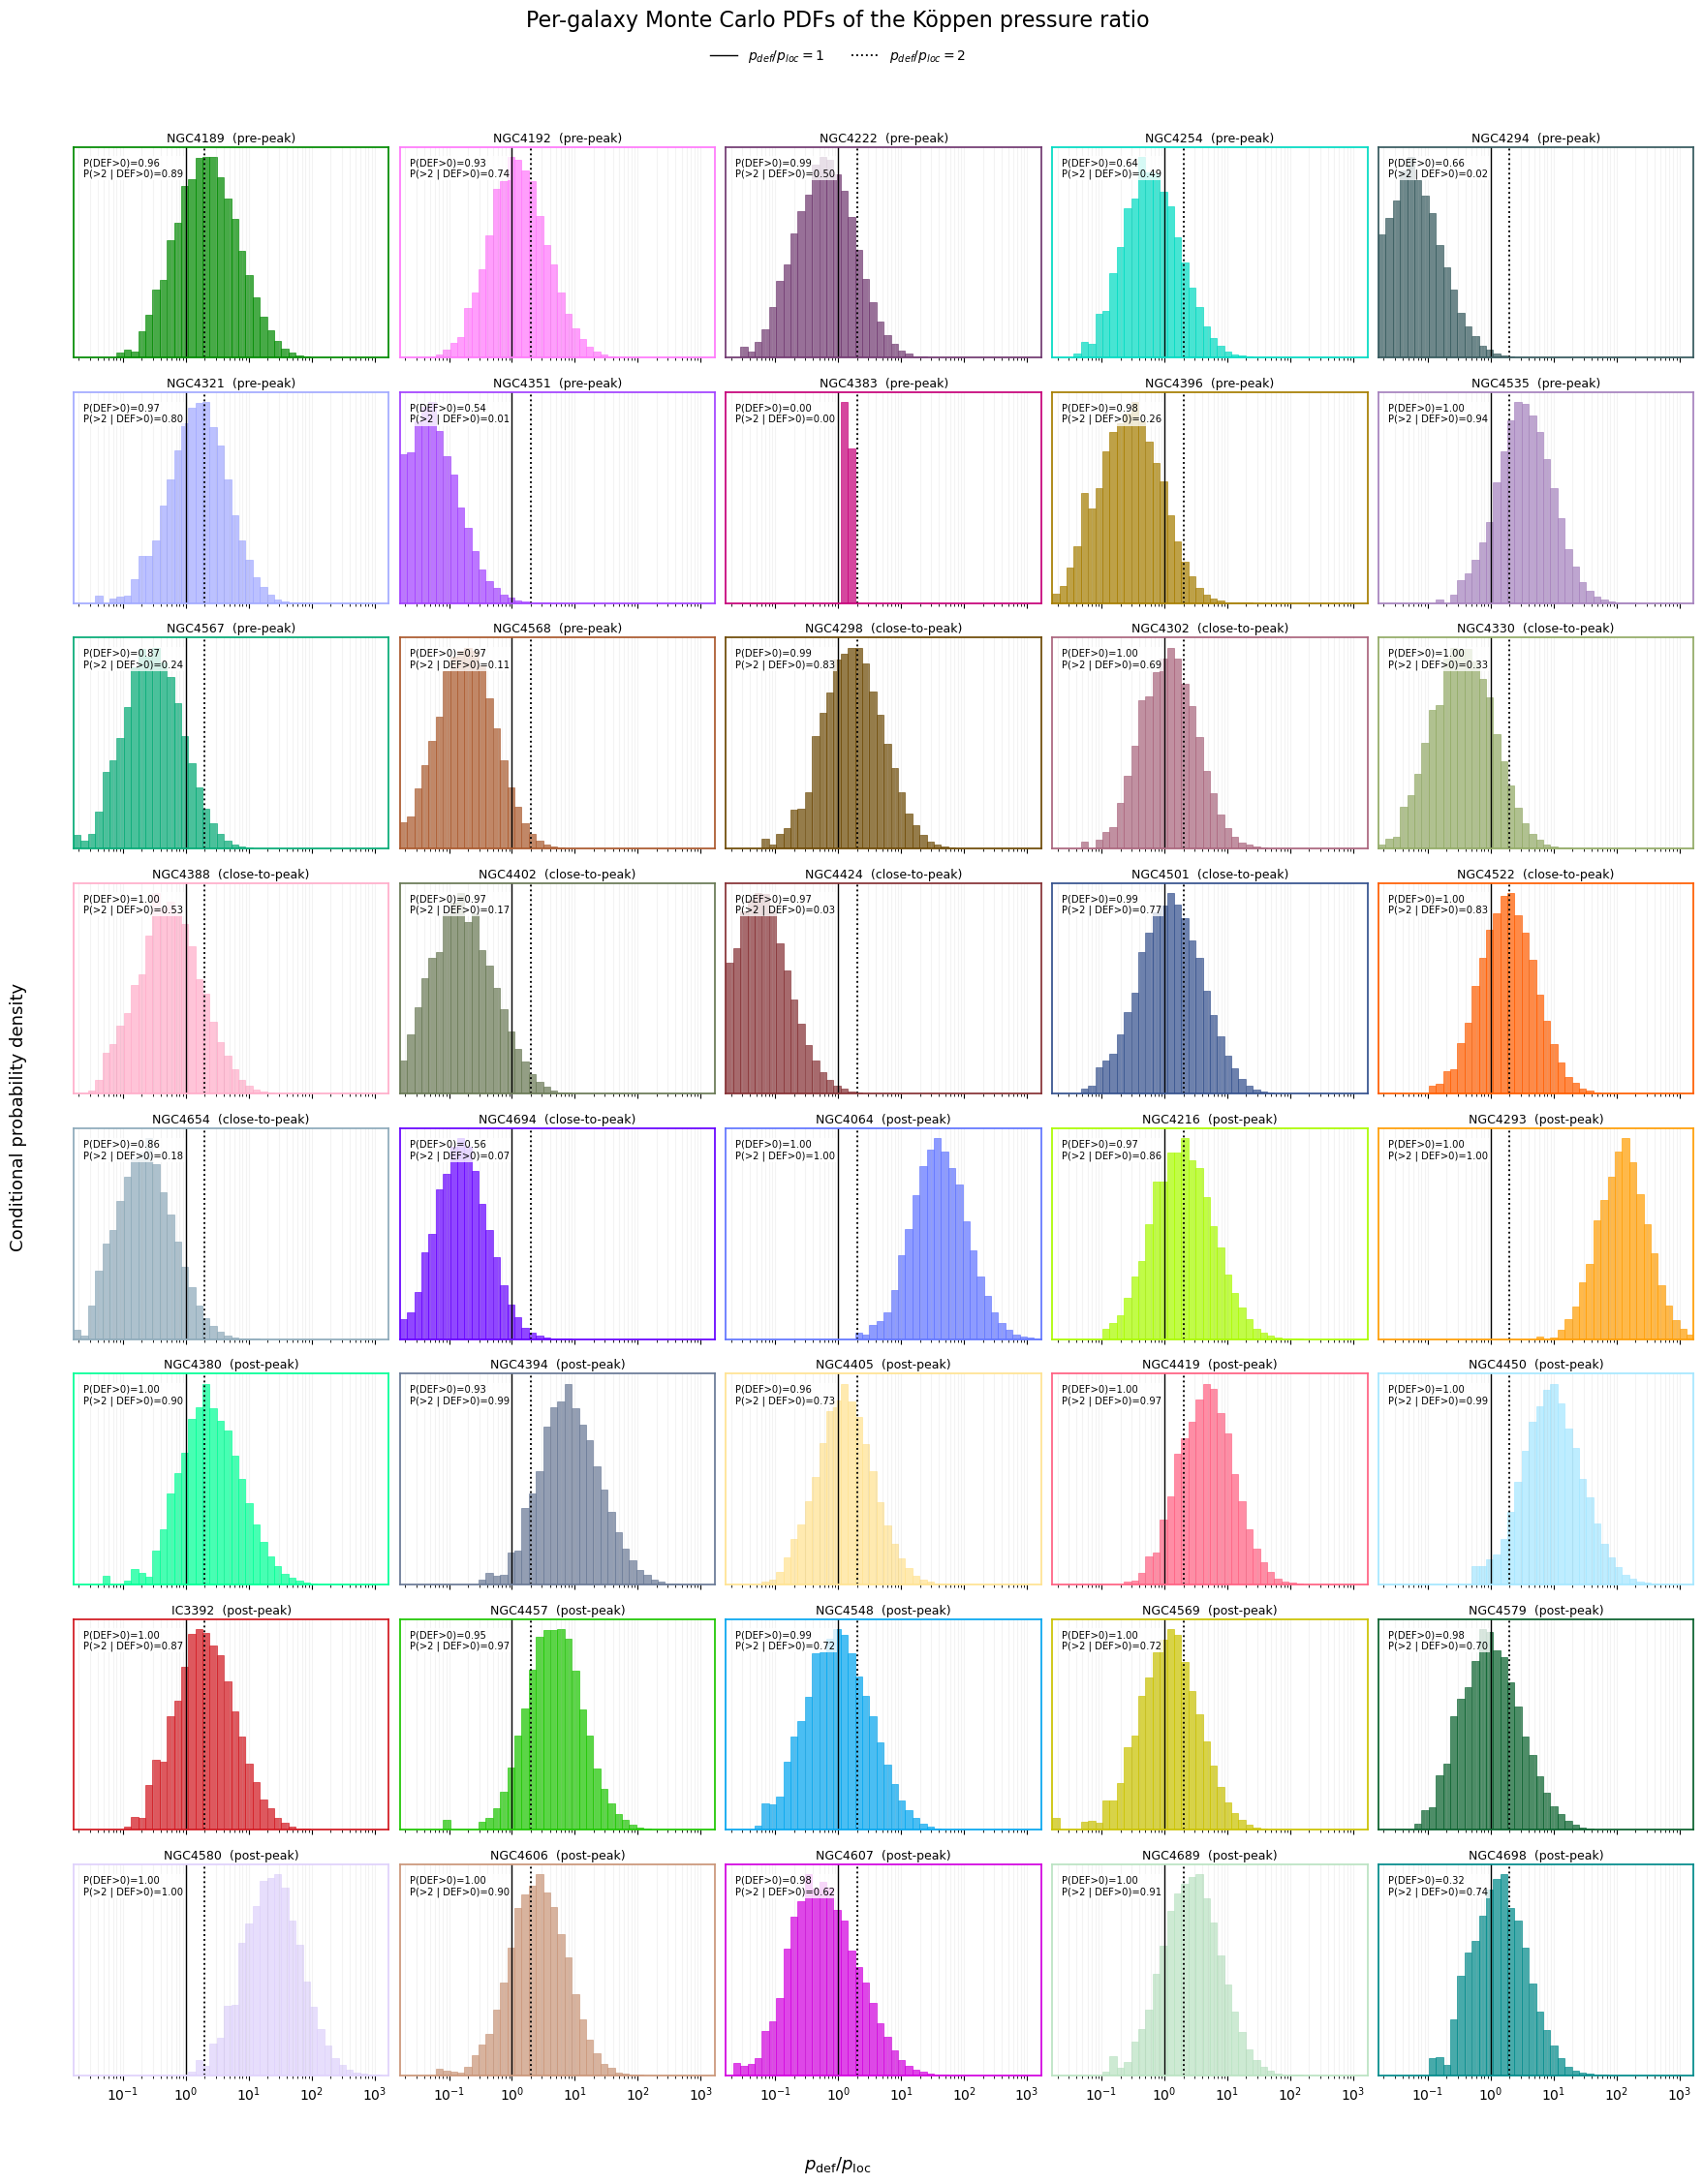

In [10]:
# Use common logarithmic bins so all 40 panels are directly comparable.
all_ratio_values = np.concatenate([values for values in ratio_draws.values() if len(values) > 0])
x_min = min(0.25, np.percentile(all_ratio_values, 0.1))
x_max = max(4.0, np.percentile(all_ratio_values, 99.9))
ratio_bins = np.geomspace(x_min, x_max, 45)

fig, axes = plt.subplots(8, 5, figsize=(18, 23), sharex=True)
axes = axes.ravel()

for ax, row in zip(axes, results.itertuples(index=False)):
    values = ratio_draws[row.Galaxy]
    if len(values) > 0:
        ax.hist(
            values,
            bins=ratio_bins,
            density=True,
            color=row.galaxy_color,
            alpha=0.72,
            edgecolor=row.galaxy_color,
            linewidth=0.6,
        )
    else:
        ax.text(0.5, 0.52, "No positive-DEF draws", transform=ax.transAxes,
                ha="center", va="center", fontsize=8)

    ax.axvline(1.0, color="black", linewidth=1.0)
    ax.axvline(2.0, color="black", linestyle=":", linewidth=1.35)
    ax.set_xscale("log")
    ax.set_xlim(x_min, x_max)
    ax.set_yticks([])
    ax.grid(axis="x", which="both", alpha=0.15)
    ax.set_title(f"{row.Galaxy}  ({row.stage_label})", fontsize=9, pad=4)
    ax.text(
        0.03, 0.95,
        f"P(DEF>0)={row.P_DEF_positive:.2f}\n"
        f"P(>2 | DEF>0)={row.P_past_given_DEF_positive:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=7.2,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 1.2},
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(row.galaxy_color)
        spine.set_linewidth(1.25)

fig.supxlabel(r"$p_{\rm def}/p_{\rm loc}$", fontsize=13, y=0.025)
fig.supylabel("Conditional probability density", fontsize=13, x=0.025)
fig.suptitle(
    "Per-galaxy Monte Carlo PDFs of the Köppen pressure ratio",
    fontsize=16, y=0.997,
)
fig.legend(
    handles=[
        Line2D([], [], color="black", linewidth=1.0, label=r"$p_{def}/p_{loc}=1$"),
        Line2D([], [], color="black", linestyle=":", linewidth=1.35,
               label=r"$p_{def}/p_{loc}=2$"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, 0.985), ncol=2, frameon=False,
)
fig.tight_layout(rect=(0.035, 0.035, 1.0, 0.965), h_pad=1.1, w_pad=0.7)
plt.show()

## 10. Main pressure-plane result

The left panel shows deterministic central $p_{\rm def}$ against central $p_{\rm loc}$. The added right panel shows the corresponding **central** ratio $p_{\rm def}/p_{\rm loc}$ galaxy by galaxy; it contains no Monte Carlo summaries. The solid and dotted reference lines mark ratios 1 and 2.

Galaxies with non-positive central deficiency have no physical deficiency-inverted stripping radius. They are not plotted in either central-value panel and are named explicitly in the right-panel title and printed text.
Every finite central-value galaxy above the factor-of-two boundary $p_{\rm def}/p_{\rm loc}>2$ is annotated by name in the new central panel.


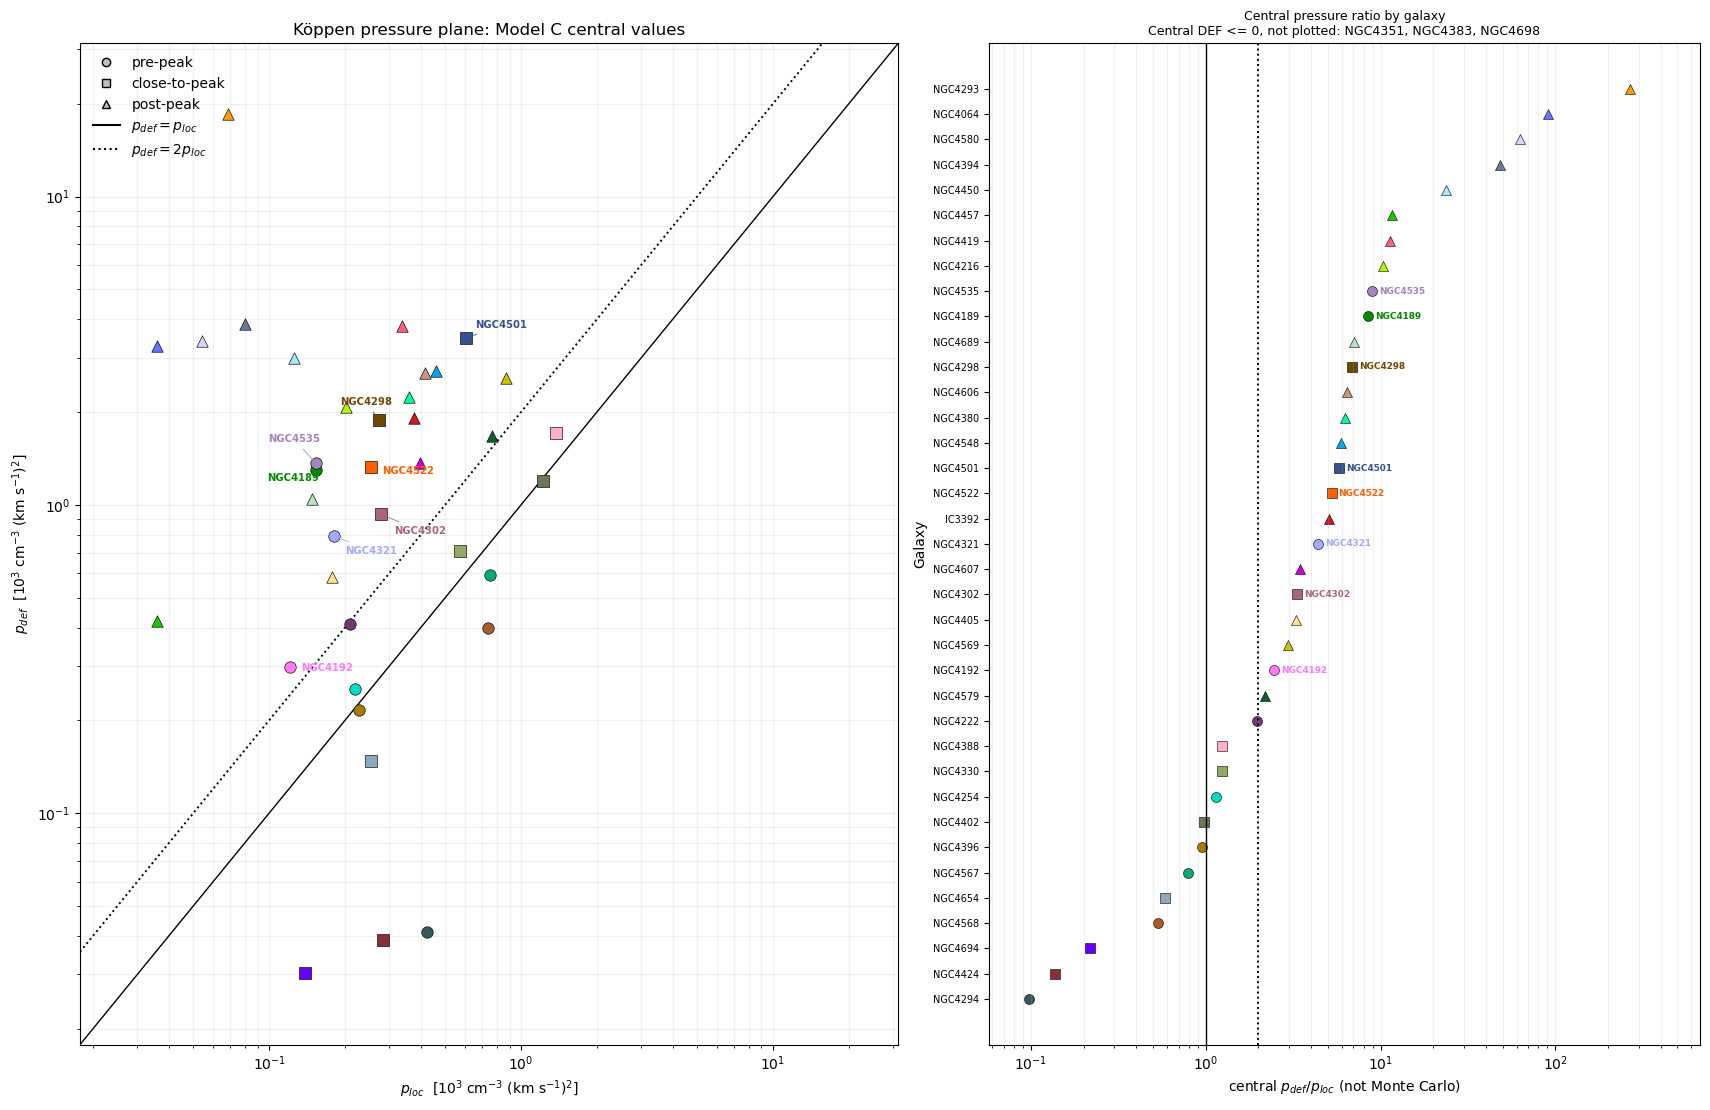

Central DEF <= 0 (not plotted in central-ratio panel): NGC4351, NGC4383, NGC4698
Pre-/close-to-peak galaxies with deterministic p_def/p_loc > 2: NGC4535, NGC4189, NGC4321, NGC4192, NGC4298, NGC4501, NGC4522, NGC4302


,Galaxy,stage_label,p_def,p_loc,pressure_ratio,Delta_RP
9,NGC4535,pre-peak,1.366,0.153,8.928,0.9507
0,NGC4189,pre-peak,1.297,0.1532,8.463,0.9275
5,NGC4321,pre-peak,0.7934,0.1805,4.397,0.6431
1,NGC4192,pre-peak,0.298,0.1206,2.471,0.3928
12,NGC4298,close-to-peak,1.884,0.273,6.901,0.8389
18,NGC4501,close-to-peak,3.473,0.602,5.769,0.7611
19,NGC4522,close-to-peak,1.33,0.2531,5.255,0.7206
13,NGC4302,close-to-peak,0.9323,0.2785,3.347,0.5247


Central-ratio pre-/close-to-peak galaxies above 2: NGC4189, NGC4192, NGC4321, NGC4535, NGC4298, NGC4302, NGC4501, NGC4522


In [11]:
# Cross-diagnostic tension: MAUVE pre-/close-to-peak but central ratio > 2.
results["deterministic_nonpost_ratio_gt2"] = (
    results["stage"].isin([1, 2])
    & np.isfinite(results["pressure_ratio"])
    & (results["pressure_ratio"] > 2.0)
)

pressure_label_offsets = {
    "NGC4535": (-34, 15), "NGC4189": (-35, -8),
    "NGC4321": (8, -13), "NGC4192": (8, -3),
    "NGC4298": (-28, 11), "NGC4501": (7, 7),
    "NGC4522": (8, -5), "NGC4302": (9, -14),
}
fig, (ax_plane, ax_ratio) = plt.subplots(
    1, 2, figsize=(17.2, 11.2), gridspec_kw={"width_ratios": [1.15, 1.0]}
)
finite = np.isfinite(results["p_def"]) & np.isfinite(results["p_loc"])

for _, row in results.loc[finite].iterrows():
    ax_plane.scatter(
        row["p_loc"], row["p_def"], s=68,
        marker=stage_markers[row["stage"]], color=row["galaxy_color"],
        edgecolor="black", linewidth=0.45, zorder=3,
    )
    if row["deterministic_nonpost_ratio_gt2"]:
        ax_plane.annotate(
            row["Galaxy"], (row["p_loc"], row["p_def"]),
            xytext=pressure_label_offsets.get(row["Galaxy"], (7, 7)),
            textcoords="offset points", fontsize=7.2, fontweight="bold",
            color=row["galaxy_color"],
            arrowprops={"arrowstyle": "-", "color": row["galaxy_color"], "lw": 0.55},
            zorder=4,
        )

lo = min(results.loc[finite, ["p_loc", "p_def"]].min()) / 1.7
hi = max(results.loc[finite, ["p_loc", "p_def"]].max()) * 1.7
grid = np.geomspace(lo, hi, 300)
ax_plane.plot(grid, grid, color="black", linewidth=1.0, label=r"$p_{def}=p_{loc}$")
ax_plane.plot(grid, 2.0 * grid, color="black", linestyle=":", linewidth=1.4,
              label=r"$p_{def}=2p_{loc}$")
ax_plane.set_xscale("log")
ax_plane.set_yscale("log")
ax_plane.set(xlim=(lo, hi), ylim=(lo, hi),
             xlabel=r"$p_{loc}$  [$10^3$ cm$^{-3}$ (km s$^{-1}$)$^2$]",
             ylabel=r"$p_{def}$  [$10^3$ cm$^{-3}$ (km s$^{-1}$)$^2$]")
ax_plane.grid(which="both", alpha=0.18)
handles = [Line2D([], [], marker=stage_markers[s], linestyle="None", color="0.35",
                  markerfacecolor="0.75", markeredgecolor="black", label=stage_labels[s])
           for s in (1, 2, 3)]
handles += [Line2D([], [], color="black", label=r"$p_{def}=p_{loc}$"),
            Line2D([], [], color="black", linestyle=":", label=r"$p_{def}=2p_{loc}$")]
ax_plane.legend(handles=handles, frameon=False, loc="upper left")
ax_plane.set_title("Köppen pressure plane: Model C central values")

# Added central-value ratio panel. It contains no Monte Carlo summaries.
central_valid = np.isfinite(results["pressure_ratio"]) & (results["pressure_ratio"] > 0)
central_ranked = results.loc[central_valid].sort_values("pressure_ratio").reset_index(drop=True)
ypos = np.arange(len(central_ranked))
for y, (_, row) in zip(ypos, central_ranked.iterrows()):
    ax_ratio.scatter(
        row["pressure_ratio"], y, s=52, color=row["galaxy_color"],
        marker=stage_markers[row["stage"]], edgecolor="black", linewidth=0.4,
    )
    if row["stage"] in (1, 2) and row["pressure_ratio"] > 2.0:
        ax_ratio.annotate(
            row["Galaxy"], (row["pressure_ratio"], y),
            xytext=(5, 0), textcoords="offset points", ha="left", va="center",
            fontsize=6.4, fontweight="bold", color=row["galaxy_color"],
        )
ax_ratio.set_xlim(
    central_ranked["pressure_ratio"].min() / 1.7,
    central_ranked["pressure_ratio"].max() * 2.5,
)
ax_ratio.axvline(1.0, color="black", linewidth=1.0)
ax_ratio.axvline(2.0, color="black", linestyle=":", linewidth=1.4)
ax_ratio.set_xscale("log")
ax_ratio.set_yticks(ypos, central_ranked["Galaxy"], fontsize=7)
ax_ratio.set_xlabel(r"central $p_{def}/p_{loc}$ (not Monte Carlo)")
ax_ratio.set_ylabel("Galaxy")
ax_ratio.grid(axis="x", which="both", alpha=0.18)
negative_central_names = results.loc[results["DEF"] <= 0, "Galaxy"].tolist()
ax_ratio.set_title(
    "Central pressure ratio by galaxy\n"
    + "Central DEF <= 0, not plotted: " + ", ".join(negative_central_names),
    fontsize=9,
)
fig.tight_layout()
plt.show()
print("Central DEF <= 0 (not plotted in central-ratio panel): " + ", ".join(negative_central_names))

deterministic_stage_tension = (
    results.loc[results["deterministic_nonpost_ratio_gt2"]]
    .sort_values(["stage", "pressure_ratio"], ascending=[True, False])
    [["Galaxy", "stage_label", "p_def", "p_loc", "pressure_ratio", "Delta_RP"]]
)
print(
    "Pre-/close-to-peak galaxies with deterministic p_def/p_loc > 2: "
    + ", ".join(deterministic_stage_tension["Galaxy"])
)
display(deterministic_stage_tension)
central_nonpost_gt2_names = results.loc[
    central_valid & results["stage"].isin([1, 2]) & (results["pressure_ratio"] > 2.0),
    "Galaxy",
].tolist()
print("Central-ratio pre-/close-to-peak galaxies above 2: " + ", ".join(central_nonpost_gt2_names))


## 11. Stage comparison: Monte Carlo and central values

The left panel shows the Monte Carlo median $\Delta_{\rm RP}$ with its 16th–84th percentile interval. The added right panel recomputes the stage comparison from the deterministic central $p_{\rm def}/p_{\rm loc}$ values only.

Central non-positive-deficiency galaxies are excluded from the right-panel points and named in its text box. Any existing Monte Carlo label selection is retained independently of the new central-value panel.
Every finite central-value galaxy above the factor-of-two boundary $p_{\rm def}/p_{\rm loc}>2$ is annotated by name in the new central panel.


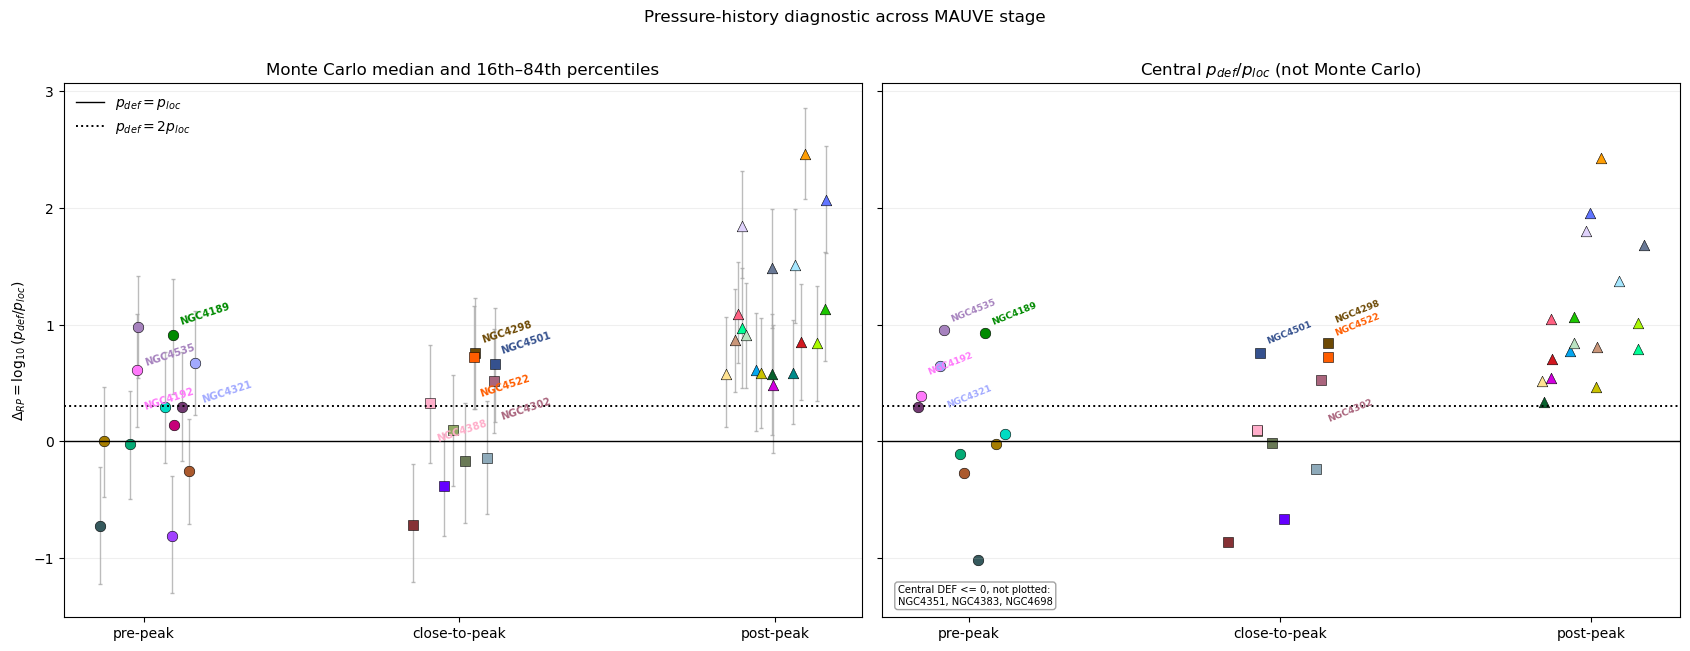

Pre-/close-to-peak galaxies satisfying the displayed MC selection: NGC4535, NGC4189, NGC4321, NGC4192, NGC4298, NGC4522, NGC4501, NGC4302, NGC4388


,Galaxy,stage_label,ratio_p16,ratio_p50,ratio_p84,P_DEF_positive,P_past_given_DEF_positive
9,NGC4535,pre-peak,3.475,9.546,26.16,0.9978,0.9401
0,NGC4189,pre-peak,2.557,8.141,24.71,0.9626,0.8864
5,NGC4321,pre-peak,1.694,4.667,13.11,0.972,0.7983
1,NGC4192,pre-peak,1.34,4.072,12.39,0.9265,0.7365
12,NGC4298,close-to-peak,1.898,5.736,17.07,0.9882,0.8279
19,NGC4522,close-to-peak,1.9,5.239,14.49,1,0.8272
18,NGC4501,close-to-peak,1.479,4.649,13.75,0.9925,0.771
13,NGC4302,close-to-peak,1.192,3.304,9.157,0.9991,0.6878
15,NGC4388,close-to-peak,0.6574,2.141,6.681,0.9975,0.5252


Central-ratio pre-/close-to-peak galaxies above 2: NGC4189, NGC4192, NGC4321, NGC4535, NGC4298, NGC4302, NGC4501, NGC4522


In [12]:
# Label pre-/close-to-peak Monte Carlo medians above the factor-of-two line.
results["mc_median_nonpost_ratio_gt2"] = (
    results["stage"].isin([1, 2])
    & np.isfinite(results["ratio_p50"])
    & (results["ratio_p50"] > 2.0)
)

fig, (ax_mc, ax_central) = plt.subplots(1, 2, figsize=(17.0, 6.4), sharey=True)
jitter_rng = np.random.default_rng(42)

for stage in (1, 2, 3):
    group = results[(results["stage"] == stage) & np.isfinite(results["Delta_RP_p50"])]
    x = stage + jitter_rng.uniform(-0.17, 0.17, len(group))
    y = group["Delta_RP_p50"].to_numpy()
    yerr = np.vstack([
        y - group["Delta_RP_p16"].to_numpy(),
        group["Delta_RP_p84"].to_numpy() - y,
    ])
    ax_mc.errorbar(x, y, yerr=yerr, fmt="none", ecolor="0.65", alpha=0.75,
                   elinewidth=1.0, capsize=1.5, zorder=1)
    for label_number, (xpos, (_, row)) in enumerate(zip(x, group.iterrows())):
        ax_mc.scatter(xpos, row["Delta_RP_p50"], s=58, color=row["galaxy_color"],
                      marker=stage_markers[stage], edgecolor="black", linewidth=0.4, zorder=2)
        if row["mc_median_nonpost_ratio_gt2"]:
            y_offset = 6 if label_number % 2 == 0 else -11
            ax_mc.annotate(
                row["Galaxy"], (xpos, row["Delta_RP_p50"]),
                xytext=(4, y_offset), textcoords="offset points",
                fontsize=7.2, fontweight="bold", color=row["galaxy_color"],
                rotation=18, ha="left", va="bottom" if y_offset > 0 else "top",
                zorder=3,
            )

ax_mc.axhline(0.0, color="black", linewidth=1.0, label=r"$p_{def}=p_{loc}$")
ax_mc.axhline(np.log10(2.0), color="black", linestyle=":", linewidth=1.4,
              label=r"$p_{def}=2p_{loc}$")
ax_mc.set_xticks([1, 2, 3], [stage_labels[s] for s in (1, 2, 3)])
ax_mc.set_ylabel(r"$\Delta_{RP}=\log_{10}(p_{def}/p_{loc})$")
ax_mc.set_title("Monte Carlo median and 16th–84th percentiles")
ax_mc.grid(axis="y", alpha=0.2)
ax_mc.legend(frameon=False)

# Added central-value stage panel. Negative/non-positive central deficiencies
# are deliberately absent because their stripping-radius inversion is undefined.
central_stage_valid = np.isfinite(results["pressure_ratio"]) & (results["pressure_ratio"] > 0)
central_jitter_rng = np.random.default_rng(43)
central_label_number = 0
for stage in (1, 2, 3):
    group = results[(results["stage"] == stage) & central_stage_valid]
    x = stage + central_jitter_rng.uniform(-0.17, 0.17, len(group))
    for xpos, (_, row) in zip(x, group.iterrows()):
        central_y = np.log10(row["pressure_ratio"])
        ax_central.scatter(
            xpos, central_y, s=58,
            color=row["galaxy_color"], marker=stage_markers[stage],
            edgecolor="black", linewidth=0.4,
        )
        if stage in (1, 2) and row["pressure_ratio"] > 2.0:
            label_offsets = [(4, 5), (4, 14), (4, -12)]
            offset = label_offsets[central_label_number % len(label_offsets)]
            ax_central.annotate(
                row["Galaxy"], (xpos, central_y), xytext=offset,
                textcoords="offset points", fontsize=6.6, fontweight="bold",
                color=row["galaxy_color"], rotation=22, ha="left",
                va="bottom" if offset[1] >= 0 else "top", zorder=3,
            )
            central_label_number += 1
ax_central.axhline(0.0, color="black", linewidth=1.0)
ax_central.axhline(np.log10(2.0), color="black", linestyle=":", linewidth=1.4)
ax_central.set_xticks([1, 2, 3], [stage_labels[s] for s in (1, 2, 3)])
ax_central.set_title("Central $p_{def}/p_{loc}$ (not Monte Carlo)")
ax_central.grid(axis="y", alpha=0.2)
negative_central_names = results.loc[results["DEF"] <= 0, "Galaxy"].tolist()
ax_central.text(
    0.02, 0.02, "Central DEF <= 0, not plotted:\n" + ", ".join(negative_central_names),
    transform=ax_central.transAxes, ha="left", va="bottom", fontsize=7.2,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "0.6", "alpha": 0.9},
)
fig.suptitle("Pressure-history diagnostic across MAUVE stage", y=1.01)
fig.tight_layout()
plt.show()

mc_stage_tension = (
    results.loc[results["mc_median_nonpost_ratio_gt2"]]
    .sort_values(["stage", "ratio_p50"], ascending=[True, False])
    [["Galaxy", "stage_label", "ratio_p16", "ratio_p50", "ratio_p84",
      "P_DEF_positive", "P_past_given_DEF_positive"]]
)
print(
    "Pre-/close-to-peak galaxies satisfying the displayed MC selection: "
    + ", ".join(mc_stage_tension["Galaxy"])
)
display(mc_stage_tension)
central_nonpost_gt2_names = results.loc[
    central_valid & results["stage"].isin([1, 2]) & (results["pressure_ratio"] > 2.0),
    "Galaxy",
].tolist()
print("Central-ratio pre-/close-to-peak galaxies above 2: " + ", ".join(central_nonpost_gt2_names))


## 12. Stage summaries and calibration sensitivity

Because the sample is modest and several uncertainties are shared systematics, the table reports robust descriptive summaries rather than a formal stage-sequence significance test. The second table asks how much the central deficiency changes if the AMIGA all-type fit is used instead of the fiducial morphology-dependent fit.

In [13]:
stage_summary = (
    results.groupby(["stage", "stage_label"], observed=True)
    .agg(
        N=("Galaxy", "size"),
        median_DEF=("DEF_p50", "median"),
        median_Delta_RP=("Delta_RP_p50", "median"),
        median_P_DEF_positive=("P_DEF_positive", "median"),
        median_P_past_given_positive=("P_past_given_DEF_positive", "median"),
        N_past_favoured=("MC_interpretation", lambda x: (x == "past-stripping favoured").sum()),
        N_ambiguous=("MC_interpretation", lambda x: (x == "ambiguous").sum()),
        N_ongoing_compatible=("MC_interpretation", lambda x: (x == "ongoing-compatible").sum()),
        N_mostly_nondeficient=("MC_interpretation", lambda x: (x == "mostly non-deficient / inversion unstable").sum()),
    )
    .reset_index()
)
display(stage_summary)

calibration_check = results[["Galaxy", "stage_label", "DEF", "DEF_all"]].copy()
calibration_check["DEF_all_minus_morph"] = calibration_check["DEF_all"] - calibration_check["DEF"]
display(calibration_check.sort_values("DEF_all_minus_morph", key=np.abs, ascending=False))
print("Median |DEF_all - DEF_morph| = "
      f"{np.median(np.abs(calibration_check['DEF_all_minus_morph'])):.3f} dex")

,stage,stage_label,N,median_DEF,median_Delta_RP,median_P_DEF_positive,median_P_past_given_positive,N_past_favoured,N_ambiguous,N_ongoing_compatible,N_mostly_nondeficient
0,1,pre-peak,12,0.3701,0.2193,0.9446,0.3769,2,6,3,1
1,2,close-to-peak,10,0.6456,0.2139,0.9904,0.4289,0,8,2,0
2,3,post-peak,18,0.8845,0.8879,0.9969,0.9004,12,5,0,1


,Galaxy,stage_label,DEF,DEF_all,DEF_all_minus_morph
27,NGC4405,post-peak,0.5491,1.099,0.55
6,NGC4351,pre-peak,-0.2297,0.3131,0.5428
7,NGC4383,pre-peak,-1.177,-0.6417,0.5356
35,NGC4580,post-peak,0.9486,1.466,0.5176
21,NGC4694,close-to-peak,0.05156,0.5583,0.5068
36,NGC4606,post-peak,1.248,1.723,0.4744
30,IC3392,post-peak,1.045,1.512,0.4672
31,NGC4457,post-peak,0.4793,0.932,0.4528
17,NGC4424,close-to-peak,0.5444,0.9863,0.442
22,NGC4064,post-peak,1.291,1.722,0.4312


Median |DEF_all - DEF_morph| = 0.127 dex


## 13. Automated QC and interpretation guardrails

These checks distinguish a notebook that merely ran from one whose key scientific joins and outputs are internally coherent.

- Every physical component must appear exactly once.
- All deterministic inputs, including the Wang cutoff and the three velocity columns, must be finite and positive where required.
- `v_upper_kms` must equal the row-wise maximum of escape and relative LOS speeds, and revised $p_{\rm loc}$ cannot be below the escape-only value.
- A positive central DEF must produce a finite radius and pressure; a non-positive DEF must not.
- Monte Carlo probabilities must stay in $[0,1]$.
- The published $p_{\rm loc}$ regression must remain within its tolerance.
- Results must include all three MAUVE stages.

Passing these checks validates the implementation and bookkeeping. It does **not** remove the stated catalogue-provenance, calibration-applicability, projection, or model-systematic limitations.

In [14]:
expected_e_vrot_used = np.where(
    np.isfinite(results["e_vrot"]) & (results["e_vrot"] > 0),
    results["e_vrot"],
    VROT_FRACTIONAL_FALLBACK * results["vrot"],
)
assert np.allclose(results["e_vrot_used"], expected_e_vrot_used, equal_nan=True)

assert len(results) == 40 and results["Galaxy"].nunique() == 40
assert set(results["stage"]) == {1, 2, 3}
assert results[["D25_kpc", "Ropt_kpc", "DHI0_Wang_kpc", "rmax_kpc", "vrot", "Rproj_mpc", "p_loc"]].notna().all().all()
assert (results[["D25_kpc", "Ropt_kpc", "DHI0_Wang_kpc", "rmax_kpc", "vrot", "v_esc_kms", "v_upper_kms", "p_loc"]] > 0).all().all()
assert np.allclose(results["v_upper_kms"], np.maximum(results["v_esc_kms"], results["v_relative_los_kms"]))
assert (results["p_loc"] >= results["p_loc_escape_only"] - 1e-12).all()

positive_def = results["DEF"] > 0
assert results.loc[positive_def, ["r_strip_kpc", "p_def", "pressure_ratio"]].notna().all().all()
assert results.loc[~positive_def, ["r_strip_kpc", "p_def", "pressure_ratio"]].isna().all().all()

probability_columns = ["P_DEF_positive", "P_past_joint", "P_past_given_DEF_positive"]
for column in probability_columns:
    finite_probability = results[column].dropna()
    assert finite_probability.between(0.0, 1.0).all(), f"Invalid probability in {column}"

assert (results["P_past_joint"] <= results["P_DEF_positive"] + 1e-12).all()
assert np.median(np.abs(paper_ploc["fractional_residual"])) < 0.10

print("All automated QC checks passed.")
print(f"Central-input positive DEF: {positive_def.sum()}/40")
print("Monte Carlo interpretation counts:")
display(results["MC_interpretation"].value_counts().rename_axis("interpretation").to_frame("N"))

All automated QC checks passed.
Central-input positive DEF: 37/40
Monte Carlo interpretation counts:


,N
interpretation,
ambiguous,19
past-stripping favoured,14
ongoing-compatible,5
mostly non-deficient / inversion unstable,2


## 14. How to read and extend this notebook

### What is ready to use

- A complete 40-galaxy table with AMIGA initial H I masses and Wang initial H I cutoffs.
- Deterministic $\mathrm{DEF}$, $r_{\rm strip}$, $p_{\rm def}$, $p_{\rm loc}$, $p_{\rm def}/p_{\rm loc}$, and $\Delta_{\rm RP}$.
- Monte Carlo intervals plus separate probabilities for having a physical positive deficiency and for exceeding the factor-of-two past-stripping threshold.
- Stage-level plots and summaries that do not feed the stage label back into the physical calculation.
- A regression check against published Köppen $p_{\rm loc}$ values.

### Limitations that must travel with any result

1. **Observed H I provenance:** `logMHI` is taken from the local MAUVE master compilation, whose per-row survey origin and uncertainty are not stored in the file. The 0.10 dex error is therefore a transparent provisional floor, not a reconstructed measurement likelihood.
2. **AMIGA applicability:** the isolated-galaxy diameter relation is used as the unperturbed baseline. Early-type objects—especially `NGC4694` with $T<0$—are extrapolation-sensitive.
3. **Projected radius and velocity:** $R_{\rm proj}$ is a lower limit to 3D radius. The adopted speed is the maximum of bound-model escape speed and observed LOS difference. An LOS-dominated row is a model-tension flag, not a rigorous 3D upper limit.
4. **Rotation speeds:** literature `e_vrot` is used where available; the 1% fallback for missing errors is deliberately narrow and does not capture disturbed or non-circular kinematics.
5. **Shared systematics:** AMIGA coefficients, Wang coefficients, common distance, ICM model, and halo model induce correlated uncertainties. The current Monte Carlo treats the quoted scatters independently per galaxy and should not be used as a hierarchical population likelihood.
6. **Interpretation labels:** the 0.16/0.84 probability labels are reporting conventions introduced here. The physically primary outputs are the continuous ratio and probability columns.

### Recommended next steps

1. Build a row-level H I provenance table and replace the provisional common error with survey-specific uncertainties.
2. Compare HyperLeda $v_{\rm rot}$ with resolved VIVA/VERTICO kinematics and flag galaxies where the scalar velocity is unreliable.
3. Add the configuration-space $p_{\rm cfg}$ diagnostic as a separate layer.
4. Recompute the Monte Carlo with shared nuisance draws for the AMIGA and Wang coefficients and Virgo ICM/halo parameters before formal population inference.
5. Compare the pressure probabilities with direct resolved-H I truncation and tail morphology on a galaxy-by-galaxy basis.

In [15]:
# Compact ranked table for immediate follow-up. Sorting by the conditional past
# probability does not hide the separate probability of positive deficiency.
ranked = results[[
    "Galaxy", "stage_label", "DEF_p50", "rmax_p50", "P_DEF_positive",
    "ratio_p50", "P_past_given_DEF_positive", "P_past_joint",
    "MC_interpretation", "amiga_applicability_note",
]].sort_values(
    ["P_past_given_DEF_positive", "P_DEF_positive"],
    ascending=False,
    na_position="last",
)
display(ranked)

# Explicit cross-diagnostic list requested for manuscript/QC follow-up. The
# union retains galaxies flagged by either the deterministic ratio or the MC
# median and shows both criteria side-by-side.
nonpost_ratio_gt2 = (
    results.loc[
        results["deterministic_nonpost_ratio_gt2"] | results["mc_median_nonpost_ratio_gt2"]
    ]
    .sort_values(["stage", "ratio_p50"], ascending=[True, False])
    [["Galaxy", "stage_label", "pressure_ratio", "ratio_p16", "ratio_p50", "ratio_p84",
      "P_DEF_positive", "P_past_given_DEF_positive",
      "deterministic_nonpost_ratio_gt2", "mc_median_nonpost_ratio_gt2"]]
)

display(Markdown(
    "### Pre-/close-to-peak galaxies above the factor-of-two boundary\n"
    "The deterministic and Monte Carlo-median flags are shown separately because "
    "they answer slightly different questions."
))
display(nonpost_ratio_gt2)

display(Markdown(
    "**Take-home rule:** use `ratio_p50` and its interval as the continuous diagnostic; "
    "read `P_past_given_DEF_positive` together with `P_DEF_positive`; inspect the named "
    "pre-/close-to-peak tension list above; and return to the provenance and applicability "
    "columns before making a claim about any individual galaxy."
))

,Galaxy,stage_label,DEF_p50,rmax_p50,P_DEF_positive,ratio_p50,P_past_given_DEF_positive,P_past_joint,MC_interpretation,amiga_applicability_note
22,NGC4064,post-peak,1.357,8.973,1,115.5,1,1,past-stripping favoured,within adopted T-bin implementation
24,NGC4293,post-peak,2.049,16.33,1,286.2,1,1,past-stripping favoured,within adopted T-bin implementation
35,NGC4580,post-peak,0.9602,4.684,0.9992,70.28,0.9996,0.9989,past-stripping favoured,within adopted T-bin implementation
29,NGC4450,post-peak,0.9949,15.86,0.9994,32.08,0.9943,0.9938,past-stripping favoured,within adopted T-bin implementation
26,NGC4394,post-peak,0.5669,11.98,0.927,30.59,0.9915,0.9191,past-stripping favoured,within adopted T-bin implementation
31,NGC4457,post-peak,0.4844,7.195,0.9479,13.72,0.9692,0.9188,past-stripping favoured,within adopted T-bin implementation
28,NGC4419,post-peak,1.302,10.14,1,12.39,0.9654,0.9654,past-stripping favoured,within adopted T-bin implementation
9,NGC4535,pre-peak,0.5655,33.02,0.9978,9.546,0.9401,0.9379,past-stripping favoured,within adopted T-bin implementation
38,NGC4689,post-peak,0.8102,16.51,0.9961,8.074,0.9082,0.9048,past-stripping favoured,within adopted T-bin implementation
25,NGC4380,post-peak,0.9246,9.717,0.9977,9.332,0.9037,0.9016,past-stripping favoured,within adopted T-bin implementation


### Pre-/close-to-peak galaxies above the factor-of-two boundary
The deterministic and Monte Carlo-median flags are shown separately because they answer slightly different questions.

,Galaxy,stage_label,pressure_ratio,ratio_p16,ratio_p50,ratio_p84,P_DEF_positive,P_past_given_DEF_positive,deterministic_nonpost_ratio_gt2,mc_median_nonpost_ratio_gt2
9,NGC4535,pre-peak,8.928,3.475,9.546,26.16,0.9978,0.9401,True,True
0,NGC4189,pre-peak,8.463,2.557,8.141,24.71,0.9626,0.8864,True,True
5,NGC4321,pre-peak,4.397,1.694,4.667,13.11,0.972,0.7983,True,True
1,NGC4192,pre-peak,2.471,1.34,4.072,12.39,0.9265,0.7365,True,True
12,NGC4298,close-to-peak,6.901,1.898,5.736,17.07,0.9882,0.8279,True,True
19,NGC4522,close-to-peak,5.255,1.9,5.239,14.49,1,0.8272,True,True
18,NGC4501,close-to-peak,5.769,1.479,4.649,13.75,0.9925,0.771,True,True
13,NGC4302,close-to-peak,3.347,1.192,3.304,9.157,0.9991,0.6878,True,True
15,NGC4388,close-to-peak,1.244,0.6574,2.141,6.681,0.9975,0.5252,False,True


**Take-home rule:** use `ratio_p50` and its interval as the continuous diagnostic; read `P_past_given_DEF_positive` together with `P_DEF_positive`; inspect the named pre-/close-to-peak tension list above; and return to the provenance and applicability columns before making a claim about any individual galaxy.